[INFO] All matched countries (Hofstede ∩ Part2): n=35
[INFO] Top-20 union (Part1+Part2 if available): n=12
[INFO] Top-20 intersection (Part1 ∩ Part2): n=4


/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[WARN] Too few points for Hofstede PDI vs mean violence (Top-20 intersection: Part1∩Part2) (n=4). Skipping.


/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[WARN] Too few points for Hofstede IDV vs mean violence (Top-20 intersection: Part1∩Part2) (n=4). Skipping.


...

[WARN] Too few points for Hofstede MAS vs mean violence (Top-20 intersection: Part1∩Part2) (n=4). Skipping.


/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[WARN] Too few points for Hofstede UAI vs mean violence (Top-20 intersection: Part1∩Part2) (n=4). Skipping.


/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_5364/1873016361.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


KeyboardInterrupt: 

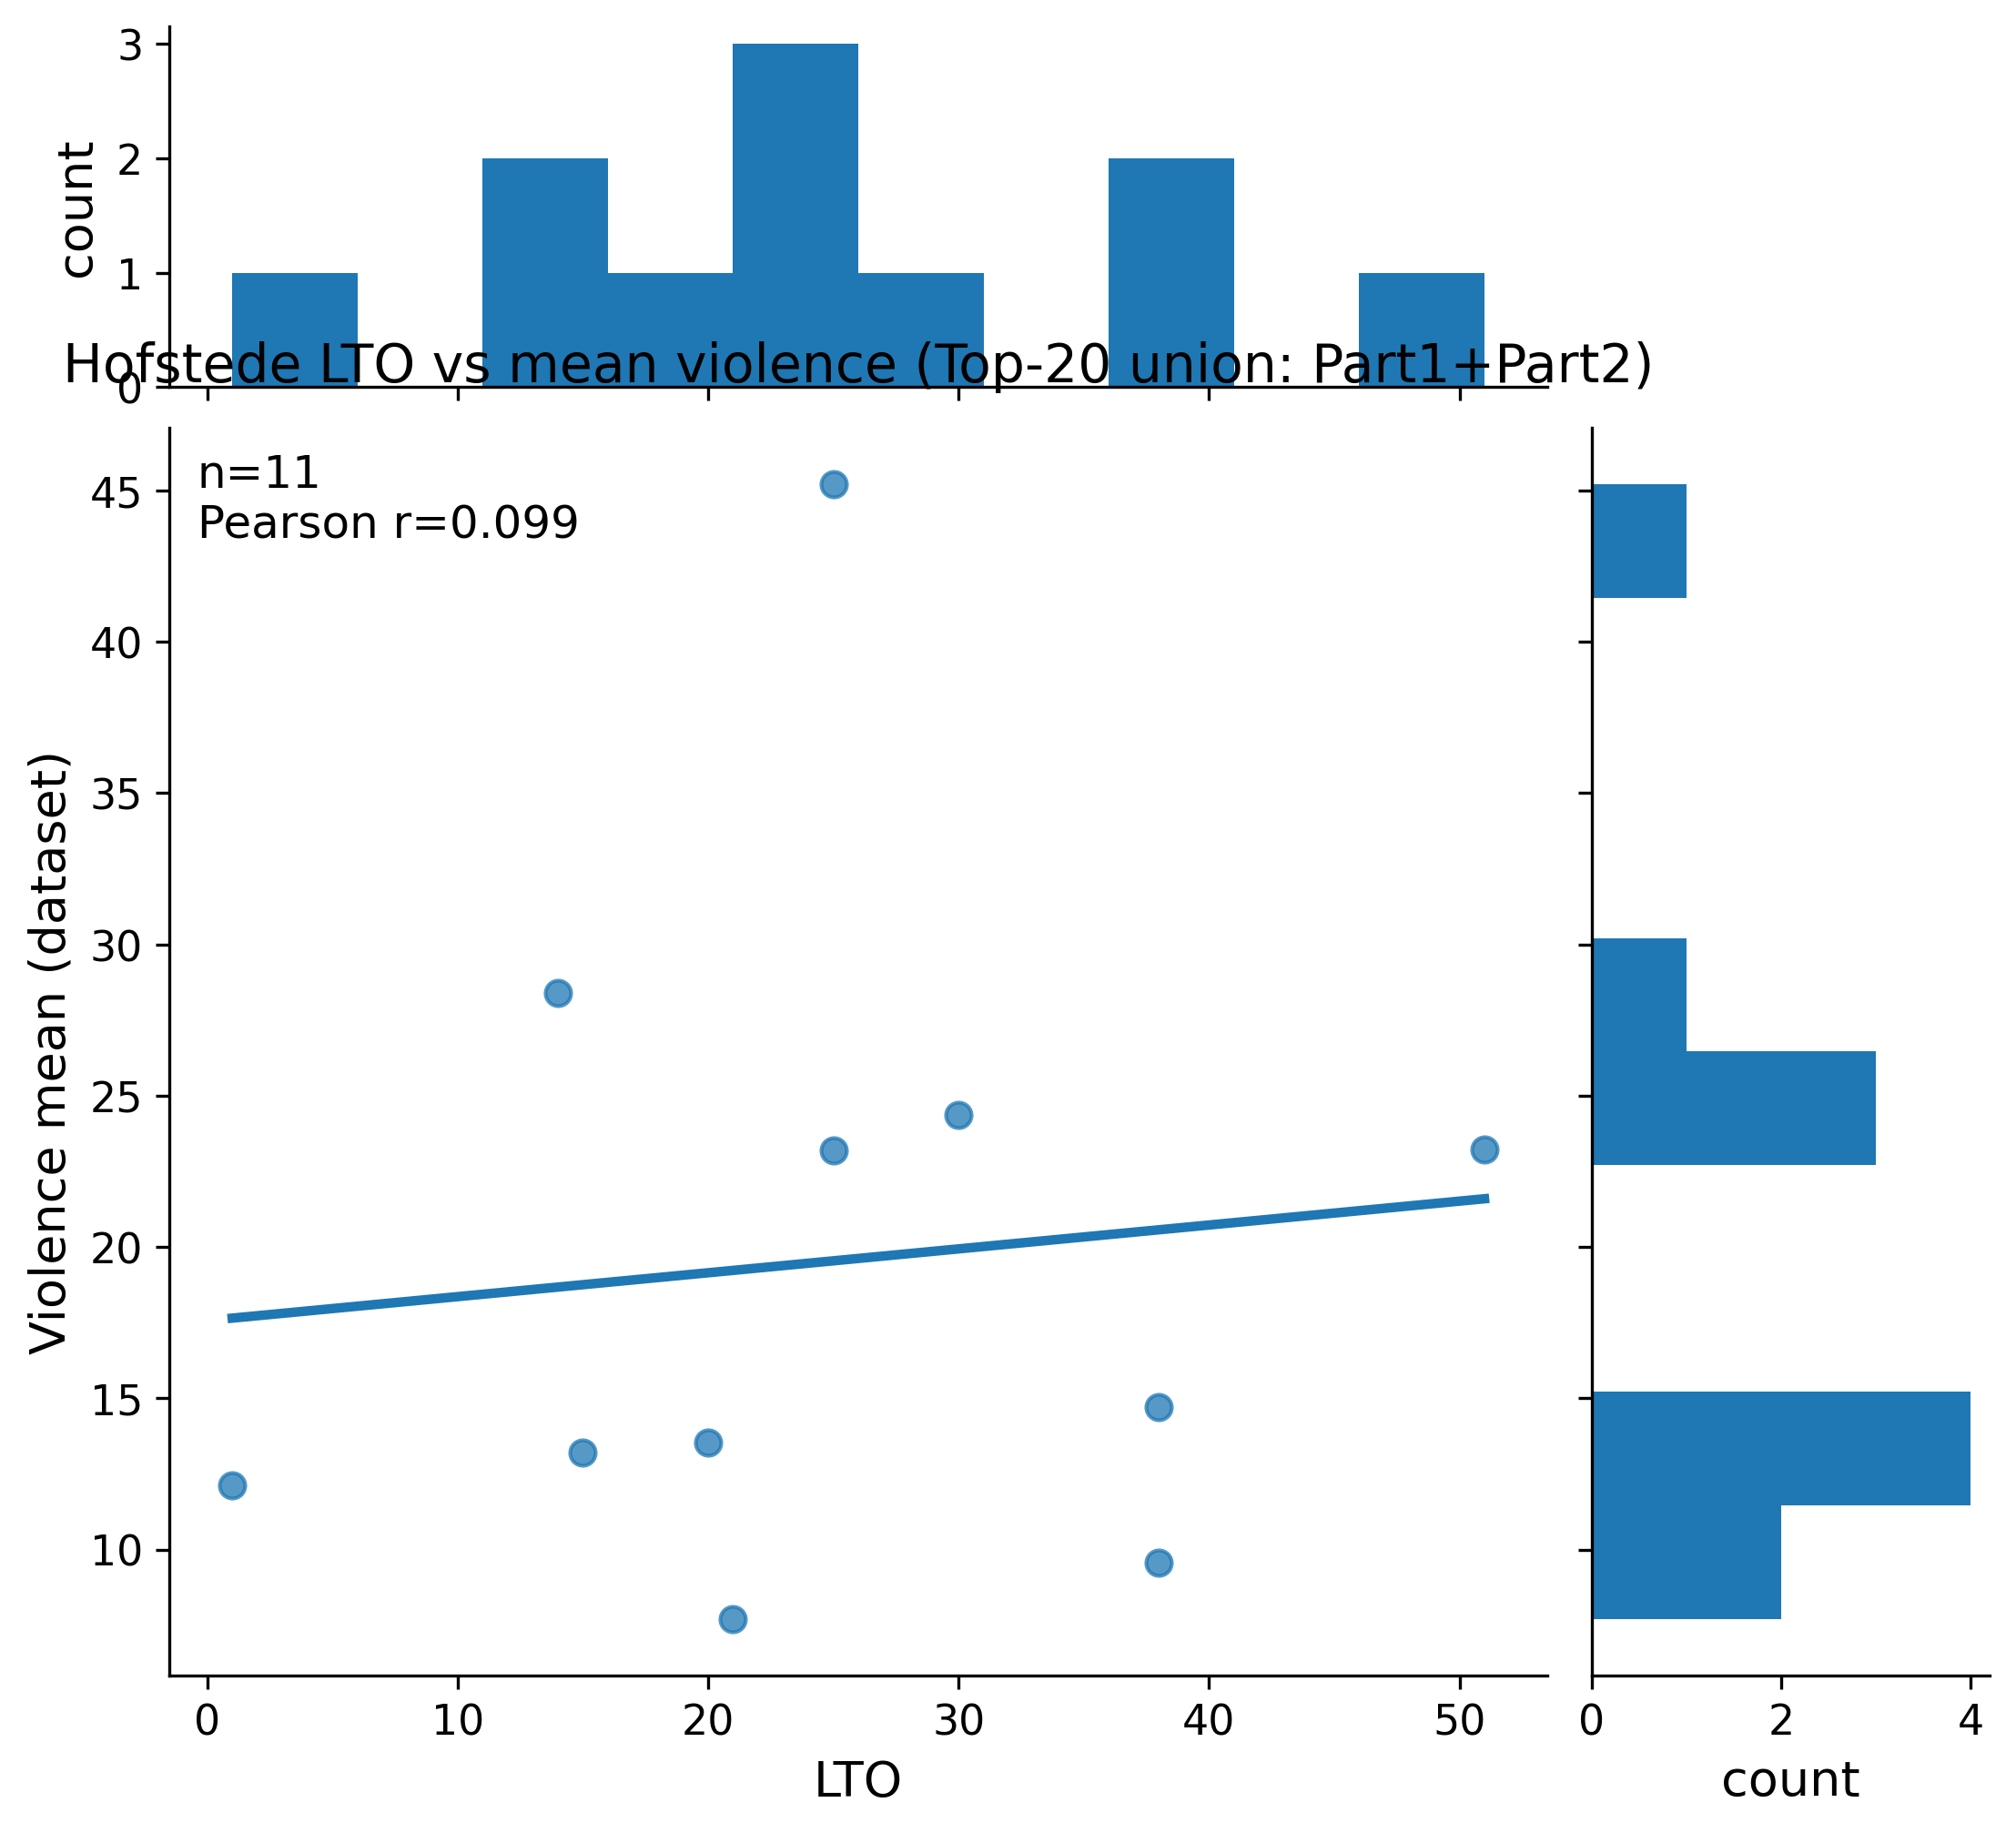

In [2]:
# hofstede_vs_violence_jointplots.py
import re
from pathlib import Path
from typing import Optional, Tuple, Set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pycountry
    HAS_PYCOUNTRY = True
except Exception:
    HAS_PYCOUNTRY = False


# =========================
# USER SETTINGS
# =========================
HOFSTEDE_CSV = Path("hofstede_country_scores.csv")

# Part 2 outputs (your current pipeline)
PART2_ROOT = Path("results_paper_ready/part2_demographics_only_xgb")
PART2_CLEAN = PART2_ROOT / "clean_modeling_table.csv"
PART2_PERF  = PART2_ROOT / "per_country_train_val_test_summary.csv"

# Optional Part 1 outputs (set these if you have them)
# If you don't have Part 1, set PART1_CLEAN=None and PART1_PERF=None below.
PART1_ROOT = Path("part1-results/results_paper_ready")  # <-- CHANGE to your real folder name
PART1_CLEAN = PART1_ROOT / "clean_modeling_table.csv"
PART1_PERF  = PART1_ROOT / "per_country_train_val_test_summary.csv"

USE_PART1 = PART1_CLEAN.exists() and PART1_PERF.exists()

TOPK = 20
R2_COL = "XGB_test_R2"   # change if your Part 1 uses different metric name
NOTE_COL = "note"        # used in your Part 2 summary

OUTDIR = Path("results_paper_ready/hofstede_vs_violence")
OUTDIR.mkdir(parents=True, exist_ok=True)

DPI = 600

# Plot look
SCATTER_ALPHA = 0.75
SCATTER_SIZE  = 45


# =========================
# Helpers
# =========================
def safe_filename(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in (" ", "-", "_") else "_" for ch in str(s)).strip()

def normalize_country_name(name: str) -> str:
    """Best-effort canonicalization for merges."""
    n = str(name).strip()

    overrides = {
        "United States of America": "United States",
        "USA": "United States",
        "Russian Federation": "Russia",
        "Viet Nam": "Vietnam",
        "Türkiye": "Turkey",
        "Cote d'Ivoire": "Ivory Coast",
        "Côte d'Ivoire": "Ivory Coast",
        "Côte d’Ivoire": "Ivory Coast",
        "Iran, Islamic Republic of": "Iran",
        "Iran (Islamic Republic of)": "Iran",
        "Bolivia (Plurinational State of)": "Bolivia",
        "Venezuela (Bolivarian Republic of)": "Venezuela",
        "Syrian Arab Republic": "Syria",
        "Lao PDR": "Laos",
    }
    if n in overrides:
        n = overrides[n]

    if HAS_PYCOUNTRY:
        try:
            return pycountry.countries.lookup(n).name
        except Exception:
            return n

    return n

def load_hofstede(hof_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(hof_csv)
    if "country" not in df.columns:
        raise ValueError(f"Hofstede file must contain 'country'. Columns: {list(df.columns)}")

    # expected Hofstede dimensions
    dims = [c for c in ["pdi", "idv", "mas", "uai", "lto", "ivr"] if c in df.columns]
    if not dims:
        raise ValueError(f"No Hofstede dimension columns found. Columns: {list(df.columns)}")

    df = df.copy()
    df["Country_NE"] = df["country"].apply(normalize_country_name)

    for c in dims:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df[["Country_NE", "country"] + dims].dropna(subset=dims, how="all")

def country_mean_violence(clean_csv: Path, country_col: str = "Country", value_col: str = "Value") -> pd.DataFrame:
    df = pd.read_csv(clean_csv)
    if country_col not in df.columns or value_col not in df.columns:
        raise ValueError(f"Missing columns in {clean_csv}: need {country_col}, {value_col}. Found {list(df.columns)}")

    d = df[[country_col, value_col]].copy()
    d[country_col] = d[country_col].astype(str).str.strip()
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")
    d = d.dropna(subset=[country_col, value_col])

    out = (
        d.groupby(country_col, as_index=False)[value_col]
        .mean()
        .rename(columns={country_col: "Country_raw", value_col: "Violence_mean"})
    )
    out["Country_NE"] = out["Country_raw"].apply(normalize_country_name)
    return out

def topk_countries(perf_csv: Path, k: int, r2_col: str, note_col: Optional[str] = None) -> Set[str]:
    df = pd.read_csv(perf_csv)
    if "Country" not in df.columns or r2_col not in df.columns:
        raise ValueError(f"{perf_csv} must contain Country and {r2_col}. Columns: {list(df.columns)}")

    d = df.copy()
    if note_col and note_col in d.columns:
        d = d[d[note_col].fillna("") == ""]

    d[r2_col] = pd.to_numeric(d[r2_col], errors="coerce")
    d = d.dropna(subset=[r2_col])

    top = d.sort_values(r2_col, ascending=False).head(k)["Country"].astype(str).tolist()
    return {normalize_country_name(c) for c in top}

def pearson_r(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 3:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])

def jointplot_like(
    df: pd.DataFrame,
    xcol: str,
    ycol: str,
    title: str,
    out_png: Path,
    out_pdf: Path,
):
    """
    Matplotlib-only jointplot style:
    - scatter + regression line (OLS)
    - top histogram (x)
    - right histogram (y)
    """
    d = df[[xcol, ycol]].dropna().copy()
    x = d[xcol].to_numpy(float)
    y = d[ycol].to_numpy(float)

    if len(d) < 5:
        print(f"[WARN] Too few points for {title} (n={len(d)}). Skipping.")
        return

    # OLS line
    b1, b0 = np.polyfit(x, y, 1)  # y = b1*x + b0
    xx = np.linspace(x.min(), x.max(), 200)
    yy = b1 * xx + b0

    r = pearson_r(x, y)

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    from matplotlib.gridspec import GridSpec

    fig = plt.figure(figsize=(8.6, 8.0), dpi=300)
    gs = GridSpec(2, 2, width_ratios=[4.5, 1.3], height_ratios=[1.3, 4.5], wspace=0.05, hspace=0.05)

    ax_top = fig.add_subplot(gs[0, 0])
    ax_sc  = fig.add_subplot(gs[1, 0])
    ax_rt  = fig.add_subplot(gs[1, 1])

    # scatter
    ax_sc.scatter(x, y, s=SCATTER_SIZE, alpha=SCATTER_ALPHA)
    ax_sc.plot(xx, yy, linewidth=2.5)

    ax_sc.set_xlabel(xcol.upper())
    ax_sc.set_ylabel("Violence mean (dataset)")

    ax_sc.set_title(title, pad=12)
    ax_sc.text(
        0.02, 0.98,
        f"n={len(d)}\nPearson r={r:.3f}",
        transform=ax_sc.transAxes,
        ha="left", va="top"
    )

    # top hist (x)
    ax_top.hist(x, bins=10, density=False)
    ax_top.set_ylabel("count")
    ax_top.tick_params(axis="x", labelbottom=False)

    # right hist (y)
    ax_rt.hist(y, bins=10, orientation="horizontal", density=False)
    ax_rt.set_xlabel("count")
    ax_rt.tick_params(axis="y", labelleft=False)

    # clean spines a bit
    for a in [ax_top, ax_sc, ax_rt]:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    fig.tight_layout()
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)


# =========================
# MAIN
# =========================
def main():
    # Load Hofstede
    hof = load_hofstede(HOFSTEDE_CSV)
    dims = [c for c in ["pdi", "idv", "mas", "uai", "lto", "ivr"] if c in hof.columns]

    # Load violence means (Part 2 always)
    v2 = country_mean_violence(PART2_CLEAN)
    v2 = v2.rename(columns={"Violence_mean": "Violence_mean_part2"})

    # Optionally Part 1
    if USE_PART1:
        v1 = country_mean_violence(PART1_CLEAN).rename(columns={"Violence_mean": "Violence_mean_part1"})
    else:
        v1 = None

    # Choose which violence mean to correlate against
    # If you want Part 2 (demographics-only table), use Violence_mean_part2.
    # If you want Part 1, switch ycol accordingly below.
    merged = hof.merge(v2[["Country_NE", "Violence_mean_part2"]], on="Country_NE", how="inner")

    # Save merged table
    merged.to_csv(OUTDIR / "hofstede_merged_with_part2_violence_mean.csv", index=False)

    # Top-20 sets
    top2 = topk_countries(PART2_PERF, TOPK, R2_COL, note_col=NOTE_COL)

    if USE_PART1:
        top1 = topk_countries(PART1_PERF, TOPK, R2_COL, note_col=NOTE_COL if NOTE_COL in pd.read_csv(PART1_PERF).columns else None)
        top_union = sorted(top1.union(top2))
        top_inter = sorted(top1.intersection(top2))
    else:
        top_union = sorted(top2)
        top_inter = []

    # Build subsets
    all_df = merged.copy()
    union_df = merged[merged["Country_NE"].isin(top_union)].copy()
    inter_df = merged[merged["Country_NE"].isin(top_inter)].copy() if top_inter else pd.DataFrame()

    print(f"[INFO] All matched countries (Hofstede ∩ Part2): n={len(all_df)}")
    print(f"[INFO] Top-{TOPK} union (Part1+Part2 if available): n={len(union_df)}")
    if top_inter:
        print(f"[INFO] Top-{TOPK} intersection (Part1 ∩ Part2): n={len(inter_df)}")

    # Plots per dimension
    for dim in dims:
        # 1) All matched
        jointplot_like(
            df=all_df,
            xcol=dim,
            ycol="Violence_mean_part2",
            title=f"Hofstede {dim.upper()} vs mean violence (All matched countries)",
            out_png=OUTDIR / f"ALL_hofstede_{dim}_vs_violence_part2.png",
            out_pdf=OUTDIR / f"ALL_hofstede_{dim}_vs_violence_part2.pdf",
        )

        # 2) Union of top performers
        jointplot_like(
            df=union_df,
            xcol=dim,
            ycol="Violence_mean_part2",
            title=f"Hofstede {dim.upper()} vs mean violence (Top-{TOPK} union: Part1+Part2)",
            out_png=OUTDIR / f"TOPUNION_hofstede_{dim}_vs_violence_part2.png",
            out_pdf=OUTDIR / f"TOPUNION_hofstede_{dim}_vs_violence_part2.pdf",
        )

        # 3) Intersection (optional)
        if not inter_df.empty:
            jointplot_like(
                df=inter_df,
                xcol=dim,
                ycol="Violence_mean_part2",
                title=f"Hofstede {dim.upper()} vs mean violence (Top-{TOPK} intersection: Part1∩Part2)",
                out_png=OUTDIR / f"TOPINTER_hofstede_{dim}_vs_violence_part2.png",
                out_pdf=OUTDIR / f"TOPINTER_hofstede_{dim}_vs_violence_part2.pdf",
            )

    print("\n[OK] Saved outputs to:")
    print(" -", OUTDIR.resolve())
    print(" - hofstede_merged_with_part2_violence_mean.csv")
    print(" - jointplot-like PNG/PDF per Hofstede dimension")

if __name__ == "__main__":
    main()


In [3]:
# hofstede_vs_violence_improved.py
# ------------------------------------------------------------
# Improved matching + robust aggregation + bootstrap CI
# Produces:
#   - merged_hofstede_violence.csv
#   - spearman_bootstrap_allcountries_part2.csv
#   - ALL_part2_joint_bestdim.(png/pdf)
#   - TOP_union_part2_joint_bestdim.(png/pdf)
#   - merge_audit_*.csv
# ------------------------------------------------------------

from __future__ import annotations

import re
from pathlib import Path
from difflib import get_close_matches

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# USER SETTINGS (EDIT THESE)
# ----------------------------
HOFSTEDE_CSV = Path("hofstede_country_scores.csv")

# IMPORTANT: point PART1_ROOT to the folder that contains:
#   - clean_modeling_table.csv
#   - per_country_train_val_test_summary.csv
#
# From the zip you shared, a common layout is:
#   part1-results/results_paper_ready/
# so you might use:
# PART1_ROOT = Path("part1-results/results_paper_ready")
PART1_ROOT = Path("part1-results/results_paper_ready")  # <-- CHANGE if needed

# Your Part2 folder (as in your code)
PART2_ROOT = Path("results_paper_ready/part2_demographics_only_xgb")

PART1_CLEAN = PART1_ROOT / "clean_modeling_table.csv"
PART2_CLEAN = PART2_ROOT / "clean_modeling_table.csv"

PART1_PERF = PART1_ROOT / "per_country_train_val_test_summary.csv"
PART2_PERF = PART2_ROOT / "per_country_train_val_test_summary.csv"

OUTDIR = Path("results_paper_ready/hofstede_vs_violence_improved")
OUTDIR.mkdir(parents=True, exist_ok=True)

TOPK = 20
BOOTSTRAP_B = 5000
RANDOM_SEED = 42

# Country-level aggregation of "Value" inside each country:
# "mean" | "median" | "trimmed_mean"
AGG_MODE = "median"
TRIM_Q = 0.10  # only used for trimmed_mean

# Hofstede dims to test:
# None -> auto-detect numeric columns excluding Country
HOFSTEDE_DIMENSIONS = None

# Plot
SCATTER_ALPHA = 0.85
FUZZY_CUTOFF = 0.86  # raise to be stricter (e.g., 0.90), lower to match more

# ----------------------------
# Helpers
# ----------------------------
def _clean_country(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_country_name(name: str) -> str:
    """Conservative normalization + a few high-impact overrides."""
    name = _clean_country(name)

    overrides = {
        "Russian Federation": "Russia",
        "Viet Nam": "Vietnam",
        "Iran, Islamic Rep.": "Iran",
        "Iran (Islamic Republic of)": "Iran",
        "Korea, Rep.": "South Korea",
        "Korea Rep.": "South Korea",
        "Korea, Dem. People's Rep.": "North Korea",
        "Czech Rep.": "Czech Republic",
        "Slovak Rep.": "Slovakia",
        "Egypt, Arab Rep.": "Egypt",
        "Yemen, Rep.": "Yemen",
        "Venezuela, RB": "Venezuela",
        "Bolivia (Plurinational State of)": "Bolivia",
        "Tanzania, United Rep.": "Tanzania",
        "United States of America": "United States",
        "USA": "United States",
        "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
        "Côte d’Ivoire": "Ivory Coast",
        "Côte d'Ivoire": "Ivory Coast",
        "Cote d'Ivoire": "Ivory Coast",
        "Lao PDR": "Laos",
        "Syrian Arab Republic": "Syria",
        "Türkiye": "Turkey",
    }
    return overrides.get(name, name)

def trimmed_mean(x: np.ndarray, q: float = 0.10) -> float:
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    lo = np.quantile(x, q)
    hi = np.quantile(x, 1 - q)
    x2 = x[(x >= lo) & (x <= hi)]
    return float(np.mean(x2)) if x2.size else float(np.mean(x))

def aggregate_violence(df: pd.DataFrame) -> pd.DataFrame:
    """Country-level violence index from clean_modeling_table.csv."""
    if "Country" not in df.columns or "Value" not in df.columns:
        raise ValueError(f"Expected columns Country and Value. Got: {list(df.columns)}")

    df = df.copy()
    df["Country_norm"] = df["Country"].map(normalize_country_name)

    out_rows = []
    for c, g in df.groupby("Country_norm"):
        vals = pd.to_numeric(g["Value"], errors="coerce").to_numpy()
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        if AGG_MODE == "mean":
            agg = float(np.mean(vals))
        elif AGG_MODE == "median":
            agg = float(np.median(vals))
        elif AGG_MODE == "trimmed_mean":
            agg = trimmed_mean(vals, q=TRIM_Q)
        else:
            raise ValueError("AGG_MODE must be mean|median|trimmed_mean")

        out_rows.append({
            "Country_norm": c,
            "Violence_index": agg,
            "n_points": int(vals.size),
            "Violence_sd": float(np.std(vals, ddof=1)) if vals.size > 1 else np.nan,
        })

    return pd.DataFrame(out_rows).sort_values("Country_norm").reset_index(drop=True)

def auto_numeric_hofstede_cols(hof: pd.DataFrame) -> list[str]:
    candidates = []
    for col in hof.columns:
        if col.lower() in {"country", "country_norm"}:
            continue
        s = pd.to_numeric(hof[col], errors="coerce")
        if np.isfinite(s).sum() >= 10:
            candidates.append(col)
    return candidates

def fuzzy_match_series(left: pd.Series, right_values: list[str], cutoff: float) -> pd.Series:
    right_values = sorted(set([str(v) for v in right_values if pd.notna(v)]))
    out = []
    for x in left.astype(str):
        m = get_close_matches(x, right_values, n=1, cutoff=cutoff)
        out.append(m[0] if m else x)
    return pd.Series(out, index=left.index)

def spearman_rho(x: np.ndarray, y: np.ndarray) -> float:
    """Spearman via rank correlation (no scipy dependency)."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    return float(np.corrcoef(rx, ry)[0, 1])

def bootstrap_ci_spearman(x: np.ndarray, y: np.ndarray, B: int, seed: int) -> tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = x.size
    if n < 5:
        return (np.nan, np.nan, np.nan)

    r0 = spearman_rho(x, y)
    boots = np.empty(B, dtype=float)
    for i in range(B):
        idx = rng.integers(0, n, size=n)
        boots[i] = spearman_rho(x[idx], y[idx])

    lo, hi = np.nanquantile(boots, [0.025, 0.975])
    return (float(r0), float(lo), float(hi))

def plot_joint_scatter(x, y, xlabel, ylabel, title, out_png: Path, out_pdf: Path):
    """Matplotlib-only joint-like plot (scatter + marginal histograms)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig = plt.figure(figsize=(8.6, 8.2), dpi=300)
    gs = fig.add_gridspec(
        2, 2, width_ratios=[4, 1.2], height_ratios=[1.2, 4],
        wspace=0.05, hspace=0.05
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[1, 1])
    ax = fig.add_subplot(gs[1, 0])

    # Scatter
    ax.scatter(x, y, s=45, alpha=SCATTER_ALPHA)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Line fit (visual aid)
    if x.size >= 2:
        b1, b0 = np.polyfit(x, y, 1)
        xx = np.linspace(np.min(x), np.max(x), 200)
        yy = b1 * xx + b0
        ax.plot(xx, yy, linewidth=2)

    # Marginals
    ax_top.hist(x, bins=12, alpha=0.6, edgecolor="black", linewidth=0.6)
    ax_right.hist(y, bins=12, orientation="horizontal", alpha=0.6, edgecolor="black", linewidth=0.6)

    for a in (ax_top, ax_right):
        a.grid(False)
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_right.set_xticks([])
    ax_right.set_yticks([])

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)

def merge_hofstede_violence(hof: pd.DataFrame, vv: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Merge with two-stage matching:
      1) normalize + direct merge on Country_norm
      2) fuzzy match for still-missing
    Returns: (merged, audit_table)
    """
    hof = hof.copy()
    vv = vv.copy()

    hof["Country_norm"] = hof["Country"].map(normalize_country_name)
    vv["Country_norm"] = vv["Country_norm"].map(normalize_country_name)

    merged = vv.merge(hof, on="Country_norm", how="left", suffixes=("", "_hof"))

    audit = pd.DataFrame({
        "Country_norm": vv["Country_norm"],
        "matched_direct": ~merged["Country"].isna() if "Country" in merged.columns else False,
    })

    # fuzzy fill still missing
    missing_mask = merged["Country"].isna()
    if missing_mask.any():
        candidates = hof["Country_norm"].dropna().astype(str).tolist()
        fuzzy_targets = fuzzy_match_series(merged.loc[missing_mask, "Country_norm"], candidates, cutoff=FUZZY_CUTOFF)
        merged.loc[missing_mask, "Country_norm_fuzzy"] = fuzzy_targets.values

        hof2 = hof.rename(columns={"Country_norm": "Country_norm_fuzzy"})
        filled = merged.loc[missing_mask].drop(columns=[c for c in hof.columns if c != "Country_norm"], errors="ignore")
        filled = filled.merge(hof2, on="Country_norm_fuzzy", how="left")

        # write back hofstede columns
        for col in hof.columns:
            if col == "Country_norm":
                continue
            merged.loc[missing_mask, col] = filled[col].values
        merged.loc[missing_mask, "Country"] = filled["Country"].values

        audit.loc[missing_mask, "matched_fuzzy"] = ~filled["Country"].isna().values
        audit.loc[missing_mask, "Country_norm_fuzzy"] = fuzzy_targets.values
    else:
        audit["matched_fuzzy"] = False
        audit["Country_norm_fuzzy"] = ""

    return merged, audit

def topk_countries(perf_csv: Path, k: int, metric: str = "XGB_test_R2") -> list[str]:
    perf = pd.read_csv(perf_csv)
    if "note" in perf.columns:
        perf = perf[perf["note"].fillna("") == ""].copy()
    perf = perf.dropna(subset=[metric])
    perf = perf.sort_values(metric, ascending=False).head(k)
    return perf["Country"].astype(str).map(normalize_country_name).tolist()

def load_hofstede(hofstede_csv: Path) -> pd.DataFrame:
    hof = pd.read_csv(hofstede_csv)

    # ---- FIX: accept 'country' or any case variant ----
    country_col = None
    for c in hof.columns:
        if str(c).strip().lower() == "country":
            country_col = c
            break
    if country_col is None:
        raise ValueError(f"Hofstede CSV must have a country column. Columns: {list(hof.columns)}")

    if country_col != "Country":
        hof = hof.rename(columns={country_col: "Country"})

    # strip + normalize
    hof["Country"] = hof["Country"].astype(str).map(_clean_country)
    return hof

def assert_exists(p: Path, label: str):
    if not p.exists():
        raise FileNotFoundError(f"[{label}] Cannot find: {p.resolve()}")

# ----------------------------
# MAIN
# ----------------------------
def main():
    # ---- Inputs ----
    assert_exists(HOFSTEDE_CSV, "HOFSTEDE_CSV")
    assert_exists(PART1_CLEAN, "PART1_CLEAN")
    assert_exists(PART2_CLEAN, "PART2_CLEAN")
    assert_exists(PART1_PERF, "PART1_PERF")
    assert_exists(PART2_PERF, "PART2_PERF")

    # Load Hofstede (fixed)
    hof = load_hofstede(HOFSTEDE_CSV)

    # Decide which Hofstede dimensions to use
    dims = HOFSTEDE_DIMENSIONS or auto_numeric_hofstede_cols(hof)
    if not dims:
        raise ValueError("No numeric Hofstede dimensions found. Check your CSV columns.")

    # Load violence tables
    part1 = pd.read_csv(PART1_CLEAN)
    part2 = pd.read_csv(PART2_CLEAN)

    v1 = aggregate_violence(part1).rename(columns={"Violence_index": "Violence_part1"})
    v2 = aggregate_violence(part2).rename(columns={"Violence_index": "Violence_part2"})

    # Merge violence means (some countries may exist in one part and not the other)
    vv = v1.merge(v2, on="Country_norm", how="outer")

    # Merge Hofstede
    hof_small = hof[["Country"] + dims].copy()
    merged, audit = merge_hofstede_violence(hof_small, vv)

    # Save merge outputs
    merged.to_csv(OUTDIR / "merged_hofstede_violence.csv", index=False)
    audit.to_csv(OUTDIR / "merge_audit_country_matching.csv", index=False)

    # ---- Analysis 1: ALL matched countries (Part2 violence vs each Hofstede dim)
    all_rows = merged.dropna(subset=["Violence_part2"]).copy()

    # require at least something numeric in hofstede columns
    all_rows = all_rows.dropna(subset=dims, how="all")
    print("\n[ALL COUNTRIES] Rows with Part2 violence:", len(all_rows))

    stats_rows = []
    for d in dims:
        x = pd.to_numeric(all_rows[d], errors="coerce").to_numpy()
        y = pd.to_numeric(all_rows["Violence_part2"], errors="coerce").to_numpy()
        r, lo, hi = bootstrap_ci_spearman(x, y, B=BOOTSTRAP_B, seed=RANDOM_SEED)
        n_eff = int(np.isfinite(x).sum() & np.isfinite(y).sum())
        stats_rows.append({
            "Hofstede_dim": d,
            "Spearman_rho": r,
            "CI95_lo": lo,
            "CI95_hi": hi,
            "n": int(np.sum(np.isfinite(x) & np.isfinite(y)))
        })

    stats = pd.DataFrame(stats_rows).sort_values("Spearman_rho", ascending=False)
    stats.to_csv(OUTDIR / "spearman_bootstrap_allcountries_part2.csv", index=False)

    print("\nTop Hofstede dims by Spearman rho (Part2 violence):")
    print(stats.head(10).to_string(index=False))

    # Plot best dimension
    best_dim = stats.iloc[0]["Hofstede_dim"] if len(stats) else None
    if best_dim and len(all_rows) >= 5:
        x = pd.to_numeric(all_rows[best_dim], errors="coerce").to_numpy()
        y = pd.to_numeric(all_rows["Violence_part2"], errors="coerce").to_numpy()
        plot_joint_scatter(
            x, y,
            xlabel=f"Hofstede: {best_dim}",
            ylabel=f"Violence index (Part2, {AGG_MODE})",
            title=f"All matched countries: Hofstede vs Violence (best dim: {best_dim})",
            out_png=OUTDIR / "ALL_part2_joint_bestdim.png",
            out_pdf=OUTDIR / "ALL_part2_joint_bestdim.pdf",
        )

    # ---- Analysis 2: union TopK Part1 + TopK Part2 (by model performance)
    top1 = set(topk_countries(PART1_PERF, TOPK))
    top2 = set(topk_countries(PART2_PERF, TOPK))
    selected = sorted(top1.union(top2))

    sel_rows = merged[merged["Country_norm"].isin(selected)].copy()
    sel_rows = sel_rows.dropna(subset=["Violence_part2"])

    (pd.DataFrame({"Country_norm_selected": selected})
        .to_csv(OUTDIR / f"selected_countries_top{TOPK}_union_part1_part2.csv", index=False))

    print(f"\n[TOP COUNTRIES] Union size Top{TOPK} (Part1 ∪ Part2):", len(selected))
    print("[TOP COUNTRIES] Rows with Part2 violence:", len(sel_rows))

    if best_dim and len(sel_rows) >= 5:
        x = pd.to_numeric(sel_rows[best_dim], errors="coerce").to_numpy()
        y = pd.to_numeric(sel_rows["Violence_part2"], errors="coerce").to_numpy()
        plot_joint_scatter(
            x, y,
            xlabel=f"Hofstede: {best_dim}",
            ylabel=f"Violence index (Part2, {AGG_MODE})",
            title=f"Top-{TOPK} Part1 ∪ Top-{TOPK} Part2: Hofstede vs Violence ({best_dim})",
            out_png=OUTDIR / "TOP_union_part2_joint_bestdim.png",
            out_pdf=OUTDIR / "TOP_union_part2_joint_bestdim.pdf",
        )

    print("\n[OK] Saved outputs to:", OUTDIR.resolve())
    print(" - merged_hofstede_violence.csv")
    print(" - merge_audit_country_matching.csv")
    print(" - spearman_bootstrap_allcountries_part2.csv")
    print(" - ALL_part2_joint_bestdim.(png/pdf)")
    print(" - TOP_union_part2_joint_bestdim.(png/pdf)")
    print(f" - selected_countries_top{TOPK}_union_part1_part2.csv")

if __name__ == "__main__":
    main()



[ALL COUNTRIES] Rows with Part2 violence: 35

Top Hofstede dims by Spearman rho (Part2 violence):
Hofstede_dim  Spearman_rho   CI95_lo  CI95_hi  n
         lto      0.152790 -0.245106 0.510652 31
         mas      0.022572 -0.344767 0.418594 35
         uai     -0.116490 -0.466917 0.260387 35
         pdi     -0.138437 -0.534380 0.258830 35
         idv     -0.321549 -0.593891 0.020561 35
         ivr     -0.346630 -0.631778 0.028349 27

[TOP COUNTRIES] Union size Top20 (Part1 ∪ Part2): 31
[TOP COUNTRIES] Rows with Part2 violence: 31

[OK] Saved outputs to: /home/carolinealves/Documents/violence-woman/results_paper_ready/hofstede_vs_violence_improved
 - merged_hofstede_violence.csv
 - merge_audit_country_matching.csv
 - spearman_bootstrap_allcountries_part2.csv
 - ALL_part2_joint_bestdim.(png/pdf)
 - TOP_union_part2_joint_bestdim.(png/pdf)
 - selected_countries_top20_union_part1_part2.csv


In [7]:
# hofstede_vs_violence_ABCD.py
# ------------------------------------------------------------
# Implements upgrades A, B, C, D in ONE script and writes each
# analysis into its own subfolder:
#
#   results_paper_ready/hofstede_vs_violence_ABCD/
#     A_iso3_matching/
#     B_item_specific_outcomes/
#     C_controls_partial_assoc/
#     D_robustness_no_selection_bias/
#
# What each upgrade does:
#   A) Improve country matching using ISO-3 codes (pycountry) + overrides + fuzzy fallback.
#   B) Reduce outcome heterogeneity: build item-specific violence indices (by Demographics Question),
#      and also optional gender stratification.
#   C) Add controls (optional): partial Spearman on residuals after regressing out controls.
#      (Requires you to provide a controls CSV; if not provided, it will be skipped with a warning.)
#   D) Avoid selection bias + robustness checks: all-countries baseline, top-performer subset flagged
#      as exploratory, and stratification by data size (n_points) + weighted correlations.
# ------------------------------------------------------------

from __future__ import annotations

import re
from pathlib import Path
from difflib import get_close_matches
from typing import Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# USER SETTINGS
# ----------------------------
HOFSTEDE_CSV = Path("hofstede_country_scores.csv")  # your file has: country,pdi,idv,mas,uai,lto,ivr

PART1_ROOT = Path("part1-results/results_paper_ready")  # adjust if needed
PART2_ROOT = Path("results_paper_ready/part2_demographics_only_xgb")

PART1_CLEAN = PART1_ROOT / "clean_modeling_table.csv"
PART2_CLEAN = PART2_ROOT / "clean_modeling_table.csv"

PART1_PERF = PART1_ROOT / "per_country_train_val_test_summary.csv"
PART2_PERF = PART2_ROOT / "per_country_train_val_test_summary.csv"

OUT_ROOT = Path("results_paper_ready/hofstede_vs_violence_ABCD")

# A) matching
FUZZY_CUTOFF = 0.86  # lower -> more matches, higher -> stricter

# B) aggregation
AGG_MODE = "median"     # "mean" | "median" | "trimmed_mean"
TRIM_Q = 0.10           # used only for trimmed_mean
MIN_N_PER_COUNTRY = 20  # drop country aggregates with too few datapoints (helps stability)

# B) item-specific outcomes
MIN_COUNTRIES_PER_ITEM = 12  # only analyze questions with at least this many matched countries
DO_GENDER_STRATA = True      # compute Female/Male/All variants if Gender exists

# C) controls (OPTIONAL)
# Provide a CSV with at least:
#   country (name) OR iso3
# and numeric columns e.g.: gdp_per_capita, gini, education_index, etc.
CONTROLS_CSV: Optional[Path] = None  # e.g., Path("controls_country_level.csv")
CONTROL_COUNTRY_COL_CANDIDATES = ("country", "Country", "COUNTRY", "name")
CONTROL_ISO3_COL_CANDIDATES = ("iso3", "ISO3", "country_iso3", "Country ISO3")

# stats / bootstrap
BOOTSTRAP_B = 5000
RANDOM_SEED = 42

# D) selection/robustness
TOPK = 20
PERF_METRIC = "XGB_test_R2"

# plot styling
SCATTER_ALPHA = 0.85
DPI_EXPORT = 600

# ----------------------------
# Optional dependency
# ----------------------------
try:
    import pycountry  # type: ignore
    HAS_PYCOUNTRY = True
except Exception:
    HAS_PYCOUNTRY = False


# ============================================================
# Helpers: strings, iso3, matching
# ============================================================
def _clean_country(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_country_name(name: str) -> str:
    """Conservative normalization + a few high-impact overrides."""
    name = _clean_country(name)

    overrides = {
        "Russian Federation": "Russia",
        "Viet Nam": "Vietnam",
        "Iran, Islamic Rep.": "Iran",
        "Iran (Islamic Republic of)": "Iran",
        "Korea, Rep.": "South Korea",
        "Korea Rep.": "South Korea",
        "Korea, Dem. People's Rep.": "North Korea",
        "Czech Rep.": "Czech Republic",
        "Slovak Rep.": "Slovakia",
        "Egypt, Arab Rep.": "Egypt",
        "Yemen, Rep.": "Yemen",
        "Venezuela, RB": "Venezuela",
        "Bolivia (Plurinational State of)": "Bolivia",
        "Tanzania, United Rep.": "Tanzania",
        "United States of America": "United States",
        "USA": "United States",
        "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
        "Côte d’Ivoire": "Ivory Coast",
        "Côte d'Ivoire": "Ivory Coast",
        "Cote d'Ivoire": "Ivory Coast",
        "Lao PDR": "Laos",
        "Syrian Arab Republic": "Syria",
        "Türkiye": "Turkey",
        "Palestine": "Palestine, State of",
        "Cabo Verde": "Cape Verde",
        "Eswatini": "Swaziland",
    }
    return overrides.get(name, name)

def _iso3_from_name(name: str) -> Optional[str]:
    """Best-effort ISO-3 using pycountry + overrides. Returns None if unknown."""
    if not name or str(name).lower() == "nan":
        return None
    name = normalize_country_name(name)

    overrides = {
        "Russia": "RUS",
        "United States": "USA",
        "United Kingdom": "GBR",
        "Ivory Coast": "CIV",
        "Vietnam": "VNM",
        "Laos": "LAO",
        "Syria": "SYR",
        "Turkey": "TUR",
        "Bolivia": "BOL",
        "Venezuela": "VEN",
        "Tanzania": "TZA",
        "South Korea": "KOR",
        "North Korea": "PRK",
        "Czech Republic": "CZE",
        "Palestine, State of": "PSE",
        "Iran": "IRN",
        "Cape Verde": "CPV",
        "Swaziland": "SWZ",
    }
    if name in overrides:
        return overrides[name]

    if not HAS_PYCOUNTRY:
        return None

    try:
        c = pycountry.countries.lookup(name)
        return getattr(c, "alpha_3", None)
    except Exception:
        return None

def fuzzy_match_series(left: pd.Series, right_values: list[str], cutoff: float) -> pd.Series:
    right_values = sorted(set([str(v) for v in right_values if pd.notna(v)]))
    out = []
    for x in left.astype(str):
        m = get_close_matches(x, right_values, n=1, cutoff=cutoff)
        out.append(m[0] if m else x)
    return pd.Series(out, index=left.index)

def assert_exists(p: Path, label: str):
    if not p.exists():
        raise FileNotFoundError(f"[{label}] Cannot find: {p.resolve()}")


# ============================================================
# Helpers: aggregation / statistics
# ============================================================
def trimmed_mean(x: np.ndarray, q: float = 0.10) -> float:
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    lo = np.quantile(x, q)
    hi = np.quantile(x, 1 - q)
    x2 = x[(x >= lo) & (x <= hi)]
    return float(np.mean(x2)) if x2.size else float(np.mean(x))

def aggregate_country_values(
    df: pd.DataFrame,
    country_col: str,
    value_col: str,
    min_n: int,
    agg_mode: str,
    trim_q: float,
) -> pd.DataFrame:
    """Aggregate df[value_col] within each country. Safe for empty outputs."""
    d = df.copy()
    d[country_col] = d[country_col].astype(str).map(normalize_country_name)
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")

    out_rows = []
    for c, g in d.groupby(country_col):
        vals = pd.to_numeric(g[value_col], errors="coerce").to_numpy()
        vals = vals[np.isfinite(vals)]
        if vals.size < min_n:
            continue

        if agg_mode == "mean":
            agg = float(np.mean(vals))
        elif agg_mode == "median":
            agg = float(np.median(vals))
        elif agg_mode == "trimmed_mean":
            agg = trimmed_mean(vals, q=trim_q)
        else:
            raise ValueError("AGG_MODE must be mean|median|trimmed_mean")

        out_rows.append({
            "Country_norm": c,
            "Violence_index": agg,
            "n_points": int(vals.size),
            "Violence_sd": float(np.std(vals, ddof=1)) if vals.size > 1 else np.nan,
        })

    # ---- key fix: if nothing passes min_n, return a correctly-shaped empty frame
    cols = ["Country_norm", "Violence_index", "n_points", "Violence_sd"]
    if not out_rows:
        return pd.DataFrame(columns=cols)

    out = pd.DataFrame(out_rows)[cols]
    return out.sort_values("Country_norm").reset_index(drop=True)
def spearman_rho(x: np.ndarray, y: np.ndarray) -> float:
    """Spearman via rank correlation (no scipy dependency)."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    return float(np.corrcoef(rx, ry)[0, 1])

def bootstrap_ci_spearman(x: np.ndarray, y: np.ndarray, B: int, seed: int) -> tuple[float, float, float, int]:
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = int(x.size)
    if n < 5:
        return (np.nan, np.nan, np.nan, n)

    r0 = spearman_rho(x, y)
    boots = np.empty(B, dtype=float)
    for i in range(B):
        idx = rng.integers(0, n, size=n)
        boots[i] = spearman_rho(x[idx], y[idx])
    lo, hi = np.nanquantile(boots, [0.025, 0.975])
    return (float(r0), float(lo), float(hi), n)

def weighted_spearman_rho(x: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    """
    Weighted Spearman (approx):
      - rank x,y
      - weighted Pearson on ranks
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]
    if x.size < 5:
        return np.nan

    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    w = w / np.sum(w)

    mx = np.sum(w * rx)
    my = np.sum(w * ry)
    cov = np.sum(w * (rx - mx) * (ry - my))
    vx = np.sum(w * (rx - mx) ** 2)
    vy = np.sum(w * (ry - my) ** 2)
    if vx <= 0 or vy <= 0:
        return np.nan
    return float(cov / np.sqrt(vx * vy))

def plot_joint_scatter(x, y, xlabel, ylabel, title, out_png: Path, out_pdf: Path):
    """Matplotlib-only joint-like plot (scatter + marginal histograms)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig = plt.figure(figsize=(8.6, 8.2), dpi=300)
    gs = fig.add_gridspec(
        2, 2, width_ratios=[4, 1.2], height_ratios=[1.2, 4],
        wspace=0.05, hspace=0.05
    )
    ax_top = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[1, 1])
    ax = fig.add_subplot(gs[1, 0])

    ax.scatter(x, y, s=45, alpha=SCATTER_ALPHA)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    if x.size >= 2:
        b1, b0 = np.polyfit(x, y, 1)
        xx = np.linspace(np.min(x), np.max(x), 200)
        yy = b1 * xx + b0
        ax.plot(xx, yy, linewidth=2)

    ax_top.hist(x, bins=12, alpha=0.6, edgecolor="black", linewidth=0.6)
    ax_right.hist(y, bins=12, orientation="horizontal", alpha=0.6, edgecolor="black", linewidth=0.6)

    for a in (ax_top, ax_right):
        a.grid(False)
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_right.set_xticks([])
    ax_right.set_yticks([])

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=DPI_EXPORT, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# Loaders (Hofstede, Controls)
# ============================================================
def load_hofstede(hofstede_csv: Path) -> pd.DataFrame:
    hof = pd.read_csv(hofstede_csv)

    # accept 'country' any case
    country_col = None
    for c in hof.columns:
        if str(c).strip().lower() == "country":
            country_col = c
            break
    if country_col is None:
        raise ValueError(f"Hofstede CSV must have a country column. Columns: {list(hof.columns)}")
    if country_col != "Country":
        hof = hof.rename(columns={country_col: "Country"})

    hof["Country"] = hof["Country"].astype(str).map(_clean_country)
    hof["Country_norm"] = hof["Country"].map(normalize_country_name)
    hof["iso3"] = hof["Country_norm"].map(_iso3_from_name)

    # numeric dims: all numeric columns excluding country fields
    dims = []
    for col in hof.columns:
        if col.lower() in {"country", "country_norm", "iso3"}:
            continue
        s = pd.to_numeric(hof[col], errors="coerce")
        if np.isfinite(s).sum() >= 10:
            dims.append(col)

    if not dims:
        raise ValueError("No numeric Hofstede dimensions detected.")
    return hof[["Country", "Country_norm", "iso3"] + dims].copy()

def _find_first_col(df: pd.DataFrame, candidates: Iterable[str]) -> Optional[str]:
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    return None

def load_controls(controls_csv: Path) -> pd.DataFrame:
    ctrl = pd.read_csv(controls_csv)

    iso_col = _find_first_col(ctrl, CONTROL_ISO3_COL_CANDIDATES)
    ctry_col = _find_first_col(ctrl, CONTROL_COUNTRY_COL_CANDIDATES)

    if iso_col is None and ctry_col is None:
        raise ValueError(
            f"Controls CSV must have iso3 or country column. Got columns: {list(ctrl.columns)}"
        )

    out = ctrl.copy()
    if iso_col is None:
        out["Country_norm"] = out[ctry_col].astype(str).map(normalize_country_name)
        out["iso3"] = out["Country_norm"].map(_iso3_from_name)
    else:
        out["iso3"] = out[iso_col].astype(str).str.upper().str.strip()

    # keep only numeric controls
    keep = ["iso3"]
    num_cols = []
    for col in out.columns:
        if col == "iso3":
            continue
        s = pd.to_numeric(out[col], errors="coerce")
        if np.isfinite(s).sum() >= 10:
            num_cols.append(col)

    if not num_cols:
        raise ValueError("Controls CSV has no usable numeric columns (>=10 finite values).")

    return out[keep + num_cols].copy()


# ============================================================
# Merging (A): ISO3 + fallback fuzzy
# ============================================================
    # --- helper: ensure we always work with a single Series, even if duplicate columns exist
    def _as_1d_series(obj):
        if isinstance(obj, pd.DataFrame):
            # if duplicate columns -> take the first one deterministically
            return obj.iloc[:, 0]
        return obj

    # figure out which column indicates "hofstede country name" after merge
    hof_country_col = "Country_hof" if "Country_hof" in merged.columns else ("Country" if "Country" in merged.columns else None)
    if hof_country_col is None:
        raise ValueError(
            "After merging, couldn't find a Hofstede country column. "
            f"Columns now: {list(merged.columns)}"
        )

    hof_country_series = _as_1d_series(merged[hof_country_col])
    missing = hof_country_series.isna()          # <-- ALWAYS a 1-D boolean Series now

    # audit base (align index with merged for safe boolean indexing)
    audit = pd.DataFrame(index=merged.index)
    audit["Country_norm"] = v["Country_norm"].to_numpy()
    audit["iso3"] = v["iso3"].to_numpy()
    audit["matched_iso3"] = ~missing

# ============================================================
# B) Item-specific outcomes
# ============================================================
def build_item_specific_country_indices(
    df_clean: pd.DataFrame,
    outdir: Path,
    which_part: str,
) -> pd.DataFrame:
    """
    Produces country-level Violence_index for:
      - ALL rows
      - per Demographics Question (item-specific)
      - optional Gender strata: Female, Male (if present)
    Returns a long table:
      Country_norm | iso3 | scope | item | Violence_index | n_points
    scope in {"ALL", "Q", "QxGender"}
    item is "ALL" or the question string or "question||gender"
    """
    outdir.mkdir(parents=True, exist_ok=True)

    needed = {"Country", "Value"}
    if not needed.issubset(df_clean.columns):
        raise ValueError(f"{which_part}: expected at least {needed}, got {set(df_clean.columns)}")

    has_q = "Demographics Question" in df_clean.columns
    has_g = "Gender" in df_clean.columns

    rows = []

    # ALL
    agg_all = aggregate_country_values(
        df_clean, country_col="Country", value_col="Value",
        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
    )
    agg_all["scope"] = "ALL"
    agg_all["item"] = "ALL"
    rows.append(agg_all)

    # Per question
    if has_q:
        for q, gq in df_clean.groupby("Demographics Question"):
            agg_q = aggregate_country_values(
                gq, country_col="Country", value_col="Value",
                min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
            )
            if len(agg_q) < MIN_COUNTRIES_PER_ITEM:
                continue
            agg_q["scope"] = "Q"
            agg_q["item"] = str(q)
            rows.append(agg_q)

            if DO_GENDER_STRATA and has_g:
                for gender, gg in gq.groupby("Gender"):
                    agg_qg = aggregate_country_values(
                        gg, country_col="Country", value_col="Value",
                        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
                    )
                    if len(agg_qg) < MIN_COUNTRIES_PER_ITEM:
                        continue
                    agg_qg["scope"] = "QxGender"
                    agg_qg["item"] = f"{q}||{gender}"
                    rows.append(agg_qg)

    out = pd.concat(rows, ignore_index=True)

    # add iso3 for later merges
    out["iso3"] = out["Country_norm"].map(_iso3_from_name)

    out.to_csv(outdir / f"{which_part}_item_specific_country_indices.csv", index=False)

    # quick audit
    audit = (
        out.groupby(["scope", "item"], as_index=False)
        .agg(n_countries=("Country_norm", "nunique"),
             median_n_points=("n_points", "median"))
        .sort_values(["scope", "n_countries"], ascending=[True, False])
    )
    audit.to_csv(outdir / f"{which_part}_item_specific_audit.csv", index=False)
    return out


# ============================================================
# C) Controls: partial Spearman on residuals
# ============================================================
def _zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x, ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return x * np.nan
    return (x - mu) / sd

def residualize(y: np.ndarray, X: np.ndarray) -> np.ndarray:
    """
    Residualize y on X via OLS with intercept, using finite rows only.
    Returns residuals aligned to original y (nan where not computable).
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    n = y.size
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    if mask.sum() < 6:
        return np.full(n, np.nan)

    y2 = y[mask]
    X2 = X[mask]
    X2 = np.column_stack([np.ones(X2.shape[0]), X2])

    # solve least squares
    beta, *_ = np.linalg.lstsq(X2, y2, rcond=None)
    yhat = X2 @ beta
    resid = y2 - yhat

    out = np.full(n, np.nan)
    out[mask] = resid
    return out

def partial_spearman_bootstrap(
    x: np.ndarray, y: np.ndarray, C: np.ndarray,
    B: int, seed: int
) -> tuple[float, float, float, int]:
    """
    Partial Spearman:
      - residualize x on C
      - residualize y on C
      - compute Spearman on residuals
      - bootstrap on rows
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    C = np.asarray(C, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(C), axis=1)
    x, y, C = x[mask], y[mask], C[mask]
    n = int(x.size)
    if n < 8:
        return (np.nan, np.nan, np.nan, n)

    # observed
    xr = residualize(x, C)
    yr = residualize(y, C)
    r0 = spearman_rho(xr, yr)

    boots = np.empty(B, dtype=float)
    for i in range(B):
        idx = rng.integers(0, n, size=n)
        xb, yb, Cb = x[idx], y[idx], C[idx]
        xbr = residualize(xb, Cb)
        ybr = residualize(yb, Cb)
        boots[i] = spearman_rho(xbr, ybr)

    lo, hi = np.nanquantile(boots, [0.025, 0.975])
    return (float(r0), float(lo), float(hi), n)


# ============================================================
# D) performance-based selection and robustness utilities
# ============================================================
def topk_countries(perf_csv: Path, k: int, metric: str) -> list[str]:
    perf = pd.read_csv(perf_csv)
    if "note" in perf.columns:
        perf = perf[perf["note"].fillna("") == ""].copy()
    perf = perf.dropna(subset=[metric])
    perf = perf.sort_values(metric, ascending=False).head(k)
    return perf["Country"].astype(str).map(normalize_country_name).tolist()


# ============================================================
# Analysis runner helpers
# ============================================================
def run_dimwise_spearman(
    merged: pd.DataFrame,
    dims: list[str],
    y_col: str,
    outdir: Path,
    tag: str,
    weight_col: Optional[str] = None,
):
    """
    Computes Spearman + bootstrap CI for each Hofstede dim vs y_col.
    Optionally compute weighted Spearman (by weight_col) as an extra column.
    Saves:
      - spearman_bootstrap_<tag>.csv
      - joint plot for best dim
    """
    outdir.mkdir(parents=True, exist_ok=True)

    stats_rows = []
    for d in dims:
        x = pd.to_numeric(merged[d], errors="coerce").to_numpy()
        y = pd.to_numeric(merged[y_col], errors="coerce").to_numpy()
        r, lo, hi, n = bootstrap_ci_spearman(x, y, B=BOOTSTRAP_B, seed=RANDOM_SEED)

        w_r = np.nan
        if weight_col is not None and weight_col in merged.columns:
            w = pd.to_numeric(merged[weight_col], errors="coerce").to_numpy()
            w_r = weighted_spearman_rho(x, y, w)

        stats_rows.append({
            "Hofstede_dim": d,
            "Spearman_rho": r,
            "CI95_lo": lo,
            "CI95_hi": hi,
            "n": n,
            "WeightedSpearman_rho": w_r,
        })

    stats = pd.DataFrame(stats_rows).sort_values("Spearman_rho", ascending=False)
    stats.to_csv(outdir / f"spearman_bootstrap_{tag}.csv", index=False)

    # plot best dim
    if len(stats) > 0:
        best_dim = str(stats.iloc[0]["Hofstede_dim"])
        x = pd.to_numeric(merged[best_dim], errors="coerce").to_numpy()
        y = pd.to_numeric(merged[y_col], errors="coerce").to_numpy()
        plot_joint_scatter(
            x, y,
            xlabel=f"Hofstede: {best_dim}",
            ylabel=y_col,
            title=f"{tag}: Hofstede vs {y_col} (best dim: {best_dim})",
            out_png=outdir / f"joint_bestdim_{tag}.png",
            out_pdf=outdir / f"joint_bestdim_{tag}.pdf",
        )

    return stats


# ============================================================
# MAIN
# ============================================================
def main():
    # ---- sanity ----
    for p, lab in [
        (HOFSTEDE_CSV, "HOFSTEDE_CSV"),
        (PART1_CLEAN, "PART1_CLEAN"),
        (PART2_CLEAN, "PART2_CLEAN"),
        (PART1_PERF, "PART1_PERF"),
        (PART2_PERF, "PART2_PERF"),
    ]:
        assert_exists(p, lab)

    OUT_ROOT.mkdir(parents=True, exist_ok=True)

    # ---- load hofstede ----
    hof = load_hofstede(HOFSTEDE_CSV)
    dims = [c for c in hof.columns if c not in {"Country", "Country_norm", "iso3"}]

    # ---- load violence clean tables ----
    part1 = pd.read_csv(PART1_CLEAN)
    part2 = pd.read_csv(PART2_CLEAN)

    # ========================================================
    # A) ISO3 matching improvement (ALL aggregated outcomes)
    # ========================================================
    outA = OUT_ROOT / "A_iso3_matching"
    outA.mkdir(parents=True, exist_ok=True)

    v1_all = aggregate_country_values(
        part1, "Country", "Value",
        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
    ).rename(columns={"Violence_index": "Violence_part1_all"})

    v2_all = aggregate_country_values(
        part2, "Country", "Value",
        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
    ).rename(columns={"Violence_index": "Violence_part2_all"})

    vv_all = v1_all.merge(v2_all, on="Country_norm", how="outer")

    mergedA, auditA = merge_iso3_then_fuzzy(hof, vv_all, outA)
    # Use Part2 as primary outcome here
    mergedA_A = mergedA.dropna(subset=["Violence_part2_all"]).copy()
    mergedA_A.to_csv(outA / "analysis_table_A.csv", index=False)

    run_dimwise_spearman(
        merged=mergedA_A,
        dims=dims,
        y_col="Violence_part2_all",
        outdir=outA,
        tag="A_allcountries_part2_all",
        weight_col="n_points",  # from the v2_all side when present
    )

    # ========================================================
    # B) Item-specific outcomes (reduce heterogeneity)
    # ========================================================
    outB = OUT_ROOT / "B_item_specific_outcomes"
    outB.mkdir(parents=True, exist_ok=True)

    idx1 = build_item_specific_country_indices(part1, outB, which_part="part1")
    idx2 = build_item_specific_country_indices(part2, outB, which_part="part2")

    # We focus on Part2 outcomes vs Hofstede
    # For each item in Part2, merge and compute dimwise Spearman, then rank items.
    items = (
        idx2[["scope", "item"]]
        .drop_duplicates()
        .sort_values(["scope", "item"])
        .to_records(index=False)
    )

    item_summary_rows = []
    for scope, item in items:
        sub = idx2[(idx2["scope"] == scope) & (idx2["item"] == item)].copy()
        if sub["Country_norm"].nunique() < MIN_COUNTRIES_PER_ITEM:
            continue

        # merge with hofstede using ISO3+fuzzy
        m, aud = merge_iso3_then_fuzzy(hof, sub.rename(columns={"Violence_index": "Violence_part2"}), outB / "tmp_merge")
        m = m.dropna(subset=["Violence_part2"]).copy()

        if len(m) < MIN_COUNTRIES_PER_ITEM:
            continue

        stats = run_dimwise_spearman(
            merged=m,
            dims=dims,
            y_col="Violence_part2",
            outdir=outB / "per_item_stats" / f"{scope}__{safe_filename(item)}",
            tag=f"{scope}__{safe_filename(item)}",
            weight_col="n_points",
        )

        # store best dim per item
        if len(stats) > 0:
            best = stats.iloc[0]
            item_summary_rows.append({
                "scope": scope,
                "item": item,
                "n_countries": int(stats.iloc[0]["n"]),
                "best_dim": str(best["Hofstede_dim"]),
                "best_rho": float(best["Spearman_rho"]),
                "best_CI_lo": float(best["CI95_lo"]),
                "best_CI_hi": float(best["CI95_hi"]),
            })

    item_summary = pd.DataFrame(item_summary_rows).sort_values("best_rho", ascending=False)
    item_summary.to_csv(outB / "item_level_summary_ranked_by_best_rho.csv", index=False)

    # ========================================================
    # C) Controls (partial association) — OPTIONAL if you provide CONTROLS_CSV
    # ========================================================
    outC = OUT_ROOT / "C_controls_partial_assoc"
    outC.mkdir(parents=True, exist_ok=True)

    if CONTROLS_CSV is None:
        (outC / "README_controls_missing.txt").write_text(
            "CONTROLS_CSV is None. Provide a country-level controls CSV to run partial association.\n"
            "Expected: iso3 or country column + numeric controls columns.\n",
            encoding="utf-8"
        )
        print("[WARN] Skipping C) because CONTROLS_CSV is None.")
    else:
        assert_exists(CONTROLS_CSV, "CONTROLS_CSV")
        ctrl = load_controls(CONTROLS_CSV)

        # Use A-merged table (Part2 aggregated) as baseline
        base = mergedA_A.copy()
        # ensure iso3 for merge
        base["iso3"] = base["Country_norm"].map(_iso3_from_name)
        base = base.merge(ctrl, on="iso3", how="left")

        # choose control columns (all numeric columns from controls)
        control_cols = [c for c in ctrl.columns if c != "iso3"]
        # drop rows missing any controls
        baseC = base.dropna(subset=["Violence_part2_all"] + control_cols, how="any").copy()
        baseC.to_csv(outC / "analysis_table_with_controls.csv", index=False)

        stats_rows = []
        for d in dims:
            x = pd.to_numeric(baseC[d], errors="coerce").to_numpy()
            y = pd.to_numeric(baseC["Violence_part2_all"], errors="coerce").to_numpy()
            Cmat = np.column_stack([pd.to_numeric(baseC[c], errors="coerce").to_numpy() for c in control_cols])

            r, lo, hi, n = partial_spearman_bootstrap(x, y, Cmat, B=BOOTSTRAP_B, seed=RANDOM_SEED)
            stats_rows.append({
                "Hofstede_dim": d,
                "PartialSpearman_rho": r,
                "CI95_lo": lo,
                "CI95_hi": hi,
                "n": n,
                "controls_used": "|".join(control_cols),
            })

        statsC = pd.DataFrame(stats_rows).sort_values("PartialSpearman_rho", ascending=False)
        statsC.to_csv(outC / "partial_spearman_bootstrap_part2_all.csv", index=False)

        if len(statsC) > 0:
            best_dim = str(statsC.iloc[0]["Hofstede_dim"])
            x = pd.to_numeric(baseC[best_dim], errors="coerce").to_numpy()
            y = pd.to_numeric(baseC["Violence_part2_all"], errors="coerce").to_numpy()
            plot_joint_scatter(
                x, y,
                xlabel=f"Hofstede: {best_dim}",
                ylabel="Violence_part2_all",
                title=f"C_controls: Raw scatter (best partial dim: {best_dim})",
                out_png=outC / "joint_raw_bestdim_controls.png",
                out_pdf=outC / "joint_raw_bestdim_controls.pdf",
            )

    # ========================================================
    # D) Robustness & avoiding selection bias
    # ========================================================
    outD = OUT_ROOT / "D_robustness_no_selection_bias"
    outD.mkdir(parents=True, exist_ok=True)

    # D1) All countries baseline (already in A but replicate explicitly)
    mergedD_all = mergedA_A.copy()
    mergedD_all.to_csv(outD / "analysis_table_allcountries.csv", index=False)
    statsD_all = run_dimwise_spearman(
        merged=mergedD_all,
        dims=dims,
        y_col="Violence_part2_all",
        outdir=outD / "D1_allcountries",
        tag="D1_allcountries_part2_all",
        weight_col="n_points",
    )

    # D2) TopK by performance (EXPLORATORY) — clearly labeled
    top1 = set(topk_countries(PART1_PERF, TOPK, metric=PERF_METRIC))
    top2 = set(topk_countries(PART2_PERF, TOPK, metric=PERF_METRIC))
    selected = sorted(top1.union(top2))
    pd.DataFrame({"Country_norm_selected": selected}).to_csv(outD / f"selected_top{TOPK}_union_part1_part2.csv", index=False)

    mergedD_top = mergedD_all[mergedD_all["Country_norm"].isin(selected)].copy()
    mergedD_top.to_csv(outD / "analysis_table_top_union_exploratory.csv", index=False)
    run_dimwise_spearman(
        merged=mergedD_top,
        dims=dims,
        y_col="Violence_part2_all",
        outdir=outD / "D2_top_union_exploratory",
        tag=f"D2_top{TOPK}_union_exploratory",
        weight_col="n_points",
    )

    # D3) Stratify by data size within country (n_points)
    if "n_points" in mergedD_all.columns:
        nn = pd.to_numeric(mergedD_all["n_points"], errors="coerce")
        q = np.nanmedian(nn.to_numpy())
        low = mergedD_all[nn < q].copy()
        high = mergedD_all[nn >= q].copy()

        low.to_csv(outD / "analysis_table_low_n.csv", index=False)
        high.to_csv(outD / "analysis_table_high_n.csv", index=False)

        run_dimwise_spearman(
            merged=low, dims=dims, y_col="Violence_part2_all",
            outdir=outD / "D3_low_n", tag="D3_low_n", weight_col="n_points"
        )
        run_dimwise_spearman(
            merged=high, dims=dims, y_col="Violence_part2_all",
            outdir=outD / "D3_high_n", tag="D3_high_n", weight_col="n_points"
        )

    # Done
    (OUT_ROOT / "README_outputs.txt").write_text(
        "Outputs written to subfolders:\n"
        "  A_iso3_matching/\n"
        "  B_item_specific_outcomes/\n"
        "  C_controls_partial_assoc/ (optional)\n"
        "  D_robustness_no_selection_bias/\n",
        encoding="utf-8"
    )

    print("\n[OK] Finished ABCD analyses.")
    print("[OK] Root folder:", OUT_ROOT.resolve())


# small utility used in B folder naming
def safe_filename(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in (" ", "-", "_") else "_" for ch in str(s)).strip()


if __name__ == "__main__":
    main()


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [9]:
# hofstede_vs_violence_ABCD.py
# ------------------------------------------------------------
# Implements upgrades A, B, C, D in ONE script and writes each
# analysis into its own subfolder:
#
#   results_paper_ready/hofstede_vs_violence_ABCD/
#     A_iso3_matching/
#     B_item_specific_outcomes/
#     C_controls_partial_assoc/
#     D_robustness_no_selection_bias/
#
# Fixes included:
#   - FIX 1: Deduplicate Hofstede by iso3 (prevents many-to-many merge expansion)
#   - FIX 2: Audit table built from merged rows (always length-consistent)
# ------------------------------------------------------------

from __future__ import annotations

import re
from pathlib import Path
from difflib import get_close_matches
from typing import Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# USER SETTINGS
# ----------------------------
HOFSTEDE_CSV = Path("hofstede_country_scores.csv")  # your file has: country,pdi,idv,mas,uai,lto,ivr

PART1_ROOT = Path("part1-results/results_paper_ready")  # adjust if needed
PART2_ROOT = Path("results_paper_ready/part2_demographics_only_xgb")

PART1_CLEAN = PART1_ROOT / "clean_modeling_table.csv"
PART2_CLEAN = PART2_ROOT / "clean_modeling_table.csv"

PART1_PERF = PART1_ROOT / "per_country_train_val_test_summary.csv"
PART2_PERF = PART2_ROOT / "per_country_train_val_test_summary.csv"

OUT_ROOT = Path("results_paper_ready/hofstede_vs_violence_ABCD")

# A) matching
FUZZY_CUTOFF = 0.86  # lower -> more matches, higher -> stricter

# B) aggregation
AGG_MODE = "median"     # "mean" | "median" | "trimmed_mean"
TRIM_Q = 0.10           # used only for trimmed_mean
MIN_N_PER_COUNTRY = 20  # drop country aggregates with too few datapoints (helps stability)

# B) item-specific outcomes
MIN_COUNTRIES_PER_ITEM = 12  # only analyze questions with at least this many matched countries
DO_GENDER_STRATA = True      # compute Female/Male/All variants if Gender exists

# C) controls (OPTIONAL)
CONTROLS_CSV: Optional[Path] = None  # e.g., Path("controls_country_level.csv")
CONTROL_COUNTRY_COL_CANDIDATES = ("country", "Country", "COUNTRY", "name")
CONTROL_ISO3_COL_CANDIDATES = ("iso3", "ISO3", "country_iso3", "Country ISO3")

# stats / bootstrap
BOOTSTRAP_B = 5000
RANDOM_SEED = 42

# D) selection/robustness
TOPK = 20
PERF_METRIC = "XGB_test_R2"

# plot styling
SCATTER_ALPHA = 0.85
DPI_EXPORT = 600

# ----------------------------
# Optional dependency
# ----------------------------
try:
    import pycountry  # type: ignore
    HAS_PYCOUNTRY = True
except Exception:
    HAS_PYCOUNTRY = False


# ============================================================
# Helpers: strings, iso3, matching
# ============================================================
def _clean_country(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s


def normalize_country_name(name: str) -> str:
    """Conservative normalization + a few high-impact overrides."""
    name = _clean_country(name)

    overrides = {
        "Russian Federation": "Russia",
        "Viet Nam": "Vietnam",
        "Iran, Islamic Rep.": "Iran",
        "Iran (Islamic Republic of)": "Iran",
        "Korea, Rep.": "South Korea",
        "Korea Rep.": "South Korea",
        "Korea, Dem. People's Rep.": "North Korea",
        "Czech Rep.": "Czech Republic",
        "Slovak Rep.": "Slovakia",
        "Egypt, Arab Rep.": "Egypt",
        "Yemen, Rep.": "Yemen",
        "Venezuela, RB": "Venezuela",
        "Bolivia (Plurinational State of)": "Bolivia",
        "Tanzania, United Rep.": "Tanzania",
        "United States of America": "United States",
        "USA": "United States",
        "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
        "Côte d’Ivoire": "Ivory Coast",
        "Côte d'Ivoire": "Ivory Coast",
        "Cote d'Ivoire": "Ivory Coast",
        "Lao PDR": "Laos",
        "Syrian Arab Republic": "Syria",
        "Türkiye": "Turkey",
        "Palestine": "Palestine, State of",
        "Cabo Verde": "Cape Verde",
        "Eswatini": "Swaziland",
    }
    return overrides.get(name, name)


def _iso3_from_name(name: str) -> Optional[str]:
    """Best-effort ISO-3 using pycountry + overrides. Returns None if unknown."""
    if not name or str(name).lower() == "nan":
        return None
    name = normalize_country_name(name)

    overrides = {
        "Russia": "RUS",
        "United States": "USA",
        "United Kingdom": "GBR",
        "Ivory Coast": "CIV",
        "Vietnam": "VNM",
        "Laos": "LAO",
        "Syria": "SYR",
        "Turkey": "TUR",
        "Bolivia": "BOL",
        "Venezuela": "VEN",
        "Tanzania": "TZA",
        "South Korea": "KOR",
        "North Korea": "PRK",
        "Czech Republic": "CZE",
        "Palestine, State of": "PSE",
        "Iran": "IRN",
        "Cape Verde": "CPV",
        "Swaziland": "SWZ",
    }
    if name in overrides:
        return overrides[name]

    if not HAS_PYCOUNTRY:
        return None

    try:
        c = pycountry.countries.lookup(name)
        return getattr(c, "alpha_3", None)
    except Exception:
        return None


def fuzzy_match_series(left: pd.Series, right_values: list[str], cutoff: float) -> pd.Series:
    right_values = sorted(set([str(v) for v in right_values if pd.notna(v)]))
    out = []
    for x in left.astype(str):
        m = get_close_matches(x, right_values, n=1, cutoff=cutoff)
        out.append(m[0] if m else x)
    return pd.Series(out, index=left.index)


def assert_exists(p: Path, label: str):
    if not p.exists():
        raise FileNotFoundError(f"[{label}] Cannot find: {p.resolve()}")


def safe_filename(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in (" ", "-", "_") else "_" for ch in str(s)).strip()


# ============================================================
# Helpers: aggregation / statistics
# ============================================================
def trimmed_mean(x: np.ndarray, q: float = 0.10) -> float:
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    lo = np.quantile(x, q)
    hi = np.quantile(x, 1 - q)
    x2 = x[(x >= lo) & (x <= hi)]
    return float(np.mean(x2)) if x2.size else float(np.mean(x))


def aggregate_country_values(
    df: pd.DataFrame,
    country_col: str,
    value_col: str,
    min_n: int,
    agg_mode: str,
    trim_q: float,
) -> pd.DataFrame:
    """Aggregate df[value_col] within each country. Safe for empty outputs."""
    d = df.copy()
    d[country_col] = d[country_col].astype(str).map(normalize_country_name)
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")

    out_rows = []
    for c, g in d.groupby(country_col):
        vals = pd.to_numeric(g[value_col], errors="coerce").to_numpy()
        vals = vals[np.isfinite(vals)]
        if vals.size < min_n:
            continue

        if agg_mode == "mean":
            agg = float(np.mean(vals))
        elif agg_mode == "median":
            agg = float(np.median(vals))
        elif agg_mode == "trimmed_mean":
            agg = trimmed_mean(vals, q=trim_q)
        else:
            raise ValueError("AGG_MODE must be mean|median|trimmed_mean")

        out_rows.append({
            "Country_norm": c,
            "Violence_index": agg,
            "n_points": int(vals.size),
            "Violence_sd": float(np.std(vals, ddof=1)) if vals.size > 1 else np.nan,
        })

    cols = ["Country_norm", "Violence_index", "n_points", "Violence_sd"]
    if not out_rows:
        return pd.DataFrame(columns=cols)

    out = pd.DataFrame(out_rows)[cols]
    return out.sort_values("Country_norm").reset_index(drop=True)


def spearman_rho(x: np.ndarray, y: np.ndarray) -> float:
    """Spearman via rank correlation (no scipy dependency)."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    return float(np.corrcoef(rx, ry)[0, 1])


def bootstrap_ci_spearman(x: np.ndarray, y: np.ndarray, B: int, seed: int) -> tuple[float, float, float, int]:
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = int(x.size)
    if n < 5:
        return (np.nan, np.nan, np.nan, n)

    r0 = spearman_rho(x, y)
    boots = np.empty(B, dtype=float)
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        boots[_] = spearman_rho(x[idx], y[idx])
    lo, hi = np.nanquantile(boots, [0.025, 0.975])
    return (float(r0), float(lo), float(hi), n)


def weighted_spearman_rho(x: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    """
    Weighted Spearman (approx):
      - rank x,y
      - weighted Pearson on ranks
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]
    if x.size < 5:
        return np.nan

    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    w = w / np.sum(w)

    mx = np.sum(w * rx)
    my = np.sum(w * ry)
    cov = np.sum(w * (rx - mx) * (ry - my))
    vx = np.sum(w * (rx - mx) ** 2)
    vy = np.sum(w * (ry - my) ** 2)
    if vx <= 0 or vy <= 0:
        return np.nan
    return float(cov / np.sqrt(vx * vy))


def plot_joint_scatter(x, y, xlabel, ylabel, title, out_png: Path, out_pdf: Path):
    """Matplotlib-only joint-like plot (scatter + marginal histograms)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig = plt.figure(figsize=(8.6, 8.2), dpi=300)
    gs = fig.add_gridspec(
        2, 2, width_ratios=[4, 1.2], height_ratios=[1.2, 4],
        wspace=0.05, hspace=0.05
    )
    ax_top = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[1, 1])
    ax = fig.add_subplot(gs[1, 0])

    ax.scatter(x, y, s=45, alpha=SCATTER_ALPHA)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    if x.size >= 2:
        b1, b0 = np.polyfit(x, y, 1)
        xx = np.linspace(np.min(x), np.max(x), 200)
        yy = b1 * xx + b0
        ax.plot(xx, yy, linewidth=2)

    ax_top.hist(x, bins=12, alpha=0.6, edgecolor="black", linewidth=0.6)
    ax_right.hist(y, bins=12, orientation="horizontal", alpha=0.6, edgecolor="black", linewidth=0.6)

    for a in (ax_top, ax_right):
        a.grid(False)
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_right.set_xticks([])
    ax_right.set_yticks([])

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=DPI_EXPORT, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# Loaders (Hofstede, Controls)
# ============================================================
def load_hofstede(hofstede_csv: Path) -> pd.DataFrame:
    hof = pd.read_csv(hofstede_csv)

    # accept 'country' any case
    country_col = None
    for c in hof.columns:
        if str(c).strip().lower() == "country":
            country_col = c
            break
    if country_col is None:
        raise ValueError(f"Hofstede CSV must have a country column. Columns: {list(hof.columns)}")
    if country_col != "Country":
        hof = hof.rename(columns={country_col: "Country"})

    hof["Country"] = hof["Country"].astype(str).map(_clean_country)
    hof["Country_norm"] = hof["Country"].map(normalize_country_name)
    hof["iso3"] = hof["Country_norm"].map(_iso3_from_name)

    # numeric dims: all numeric columns excluding country fields
    dims = []
    for col in hof.columns:
        if col.lower() in {"country", "country_norm", "iso3"}:
            continue
        s = pd.to_numeric(hof[col], errors="coerce")
        if np.isfinite(s).sum() >= 10:
            dims.append(col)

    if not dims:
        raise ValueError("No numeric Hofstede dimensions detected.")

    out = hof[["Country", "Country_norm", "iso3"] + dims].copy()

    # -------------------------
    # FIX 1: ensure unique iso3
    # -------------------------
    out["iso3"] = out["iso3"].replace({None: np.nan, "None": np.nan}).astype("string").str.upper().str.strip()
    before = len(out)
    # keep first non-null iso3 row; if iso3 is NaN keep those too but they won't join
    out = out.sort_values(["iso3", "Country_norm"]).drop_duplicates(subset=["iso3"], keep="first")
    after = len(out)
    if after != before:
        print(f"[WARN] Hofstede had duplicate iso3 rows; kept first per iso3. {before} -> {after}")

    return out


def _find_first_col(df: pd.DataFrame, candidates: Iterable[str]) -> Optional[str]:
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    return None


def load_controls(controls_csv: Path) -> pd.DataFrame:
    ctrl = pd.read_csv(controls_csv)

    iso_col = _find_first_col(ctrl, CONTROL_ISO3_COL_CANDIDATES)
    ctry_col = _find_first_col(ctrl, CONTROL_COUNTRY_COL_CANDIDATES)

    if iso_col is None and ctry_col is None:
        raise ValueError(
            f"Controls CSV must have iso3 or country column. Got columns: {list(ctrl.columns)}"
        )

    out = ctrl.copy()
    if iso_col is None:
        out["Country_norm"] = out[ctry_col].astype(str).map(normalize_country_name)
        out["iso3"] = out["Country_norm"].map(_iso3_from_name)
    else:
        out["iso3"] = out[iso_col].astype(str).str.upper().str.strip()

    keep = ["iso3"]
    num_cols = []
    for col in out.columns:
        if col == "iso3":
            continue
        s = pd.to_numeric(out[col], errors="coerce")
        if np.isfinite(s).sum() >= 10:
            num_cols.append(col)

    if not num_cols:
        raise ValueError("Controls CSV has no usable numeric columns (>=10 finite values).")

    out = out[keep + num_cols].copy()
    out["iso3"] = out["iso3"].astype(str).str.upper().str.strip()
    out = out.drop_duplicates(subset=["iso3"], keep="first")
    return out


# ============================================================
# Merging (A): ISO3 + fallback fuzzy
# ============================================================
def merge_iso3_then_fuzzy(
    hof: pd.DataFrame,
    violence_country: pd.DataFrame,
    outdir: Path
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns merged table and an audit table.

    FIX 2: audit is built from merged, so it never length-mismatches
    even if the join expands for any reason.
    """
    v = violence_country.copy()
    h = hof.copy()

    def _as_1d_series(obj) -> pd.Series:
        if isinstance(obj, pd.DataFrame):
            return obj.iloc[:, 0]
        return obj

    # normalize + iso3
    v["Country_norm"] = v["Country_norm"].astype(str).map(normalize_country_name)
    v["iso3"] = v["Country_norm"].map(_iso3_from_name)
    v["iso3"] = v["iso3"].replace({None: np.nan, "None": np.nan}).astype("string").str.upper().str.strip()

    h["Country_norm"] = h["Country_norm"].astype(str).map(normalize_country_name)
    h["iso3"] = h["iso3"].replace({None: np.nan, "None": np.nan}).astype("string").str.upper().str.strip()

    # final safety: ensure h unique iso3 (should already be from load_hofstede)
    h = h.drop_duplicates(subset=["iso3"], keep="first")

    merged = v.merge(h, on="iso3", how="left", suffixes=("", "_hof"))

    hof_country_col = "Country_hof" if "Country_hof" in merged.columns else ("Country" if "Country" in merged.columns else None)
    if hof_country_col is None:
        raise ValueError(
            "After merging, couldn't find a Hofstede country column. "
            f"Columns now: {list(merged.columns)}"
        )

    hof_country_series = _as_1d_series(merged[hof_country_col])
    missing = hof_country_series.isna()  # 1-D mask

    # -------------------------
    # FIX 2: audit from merged
    # -------------------------
    audit = pd.DataFrame(index=merged.index)
    audit["Country_norm"] = merged["Country_norm"].astype(str).to_numpy()
    audit["iso3"] = merged["iso3"].astype(str).to_numpy()
    audit["matched_iso3"] = (~missing).to_numpy()

    if missing.any():
        candidates = h["Country_norm"].dropna().astype(str).tolist()
        fuzzy_target = fuzzy_match_series(
            merged.loc[missing, "Country_norm"],
            candidates,
            cutoff=FUZZY_CUTOFF
        )

        audit.loc[missing, "Country_norm_fuzzy"] = fuzzy_target.to_numpy()

        h2 = h.rename(columns={"Country_norm": "Country_norm_fuzzy"})
        tmp = merged.loc[missing].copy()
        tmp["Country_norm_fuzzy"] = fuzzy_target.to_numpy()

        filled = tmp.merge(h2, on="Country_norm_fuzzy", how="left", suffixes=("", "_fuzzyfill"))

        hof_cols = [c for c in h.columns if c not in {"Country_norm", "iso3"}]
        for col in hof_cols:
            if col in merged.columns:
                merged.loc[missing, col] = filled[col].to_numpy()
            else:
                merged[col] = np.nan
                merged.loc[missing, col] = filled[col].to_numpy()

        filled_country_col = "Country" if "Country" in filled.columns else ("Country_hof" if "Country_hof" in filled.columns else None)
        if filled_country_col is None:
            any_dim = next((c for c in h.columns if c not in {"Country_norm", "iso3", "Country"}), None)
            audit.loc[missing, "matched_fuzzy"] = (~filled[any_dim].isna().to_numpy()) if any_dim else False
        else:
            fcs = filled[filled_country_col]
            if isinstance(fcs, pd.DataFrame):
                fcs = fcs.iloc[:, 0]
            audit.loc[missing, "matched_fuzzy"] = (~fcs.isna()).to_numpy()
    else:
        audit["Country_norm_fuzzy"] = ""
        audit["matched_fuzzy"] = False

    outdir.mkdir(parents=True, exist_ok=True)
    merged.to_csv(outdir / "merged_iso3_then_fuzzy.csv", index=False)
    audit.to_csv(outdir / "merge_audit_iso3_then_fuzzy.csv", index=False)
    return merged, audit


# ============================================================
# B) Item-specific outcomes
# ============================================================
def build_item_specific_country_indices(
    df_clean: pd.DataFrame,
    outdir: Path,
    which_part: str,
) -> pd.DataFrame:
    """
    Produces country-level Violence_index for:
      - ALL rows
      - per Demographics Question (item-specific)
      - optional Gender strata: Female, Male (if present)
    Returns a long table.
    """
    outdir.mkdir(parents=True, exist_ok=True)

    needed = {"Country", "Value"}
    if not needed.issubset(df_clean.columns):
        raise ValueError(f"{which_part}: expected at least {needed}, got {set(df_clean.columns)}")

    has_q = "Demographics Question" in df_clean.columns
    has_g = "Gender" in df_clean.columns

    rows = []

    agg_all = aggregate_country_values(
        df_clean, country_col="Country", value_col="Value",
        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
    )
    agg_all["scope"] = "ALL"
    agg_all["item"] = "ALL"
    rows.append(agg_all)

    if has_q:
        for q, gq in df_clean.groupby("Demographics Question"):
            agg_q = aggregate_country_values(
                gq, country_col="Country", value_col="Value",
                min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
            )
            if len(agg_q) < MIN_COUNTRIES_PER_ITEM:
                continue
            agg_q["scope"] = "Q"
            agg_q["item"] = str(q)
            rows.append(agg_q)

            if DO_GENDER_STRATA and has_g:
                for gender, gg in gq.groupby("Gender"):
                    agg_qg = aggregate_country_values(
                        gg, country_col="Country", value_col="Value",
                        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
                    )
                    if len(agg_qg) < MIN_COUNTRIES_PER_ITEM:
                        continue
                    agg_qg["scope"] = "QxGender"
                    agg_qg["item"] = f"{q}||{gender}"
                    rows.append(agg_qg)

    out = pd.concat(rows, ignore_index=True)
    out["iso3"] = out["Country_norm"].map(_iso3_from_name)

    out.to_csv(outdir / f"{which_part}_item_specific_country_indices.csv", index=False)

    audit = (
        out.groupby(["scope", "item"], as_index=False)
        .agg(n_countries=("Country_norm", "nunique"),
             median_n_points=("n_points", "median"))
        .sort_values(["scope", "n_countries"], ascending=[True, False])
    )
    audit.to_csv(outdir / f"{which_part}_item_specific_audit.csv", index=False)
    return out


# ============================================================
# C) Controls: partial Spearman on residuals
# ============================================================
def residualize(y: np.ndarray, X: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    n = y.size
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    if mask.sum() < 6:
        return np.full(n, np.nan)

    y2 = y[mask]
    X2 = X[mask]
    X2 = np.column_stack([np.ones(X2.shape[0]), X2])

    beta, *_ = np.linalg.lstsq(X2, y2, rcond=None)
    yhat = X2 @ beta
    resid = y2 - yhat

    out = np.full(n, np.nan)
    out[mask] = resid
    return out


def partial_spearman_bootstrap(
    x: np.ndarray, y: np.ndarray, C: np.ndarray,
    B: int, seed: int
) -> tuple[float, float, float, int]:
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    C = np.asarray(C, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(C), axis=1)
    x, y, C = x[mask], y[mask], C[mask]
    n = int(x.size)
    if n < 8:
        return (np.nan, np.nan, np.nan, n)

    xr = residualize(x, C)
    yr = residualize(y, C)
    r0 = spearman_rho(xr, yr)

    boots = np.empty(B, dtype=float)
    for i in range(B):
        idx = rng.integers(0, n, size=n)
        xb, yb, Cb = x[idx], y[idx], C[idx]
        boots[i] = spearman_rho(residualize(xb, Cb), residualize(yb, Cb))

    lo, hi = np.nanquantile(boots, [0.025, 0.975])
    return (float(r0), float(lo), float(hi), n)


# ============================================================
# D) performance-based selection and robustness utilities
# ============================================================
def topk_countries(perf_csv: Path, k: int, metric: str) -> list[str]:
    perf = pd.read_csv(perf_csv)
    if "note" in perf.columns:
        perf = perf[perf["note"].fillna("") == ""].copy()
    perf = perf.dropna(subset=[metric])
    perf = perf.sort_values(metric, ascending=False).head(k)
    return perf["Country"].astype(str).map(normalize_country_name).tolist()


# ============================================================
# Analysis runner helpers
# ============================================================
def run_dimwise_spearman(
    merged: pd.DataFrame,
    dims: list[str],
    y_col: str,
    outdir: Path,
    tag: str,
    weight_col: Optional[str] = None,
):
    outdir.mkdir(parents=True, exist_ok=True)

    stats_rows = []
    for d in dims:
        x = pd.to_numeric(merged[d], errors="coerce").to_numpy()
        y = pd.to_numeric(merged[y_col], errors="coerce").to_numpy()
        r, lo, hi, n = bootstrap_ci_spearman(x, y, B=BOOTSTRAP_B, seed=RANDOM_SEED)

        w_r = np.nan
        if weight_col is not None and weight_col in merged.columns:
            w = pd.to_numeric(merged[weight_col], errors="coerce").to_numpy()
            w_r = weighted_spearman_rho(x, y, w)

        stats_rows.append({
            "Hofstede_dim": d,
            "Spearman_rho": r,
            "CI95_lo": lo,
            "CI95_hi": hi,
            "n": n,
            "WeightedSpearman_rho": w_r,
        })

    stats = pd.DataFrame(stats_rows).sort_values("Spearman_rho", ascending=False)
    stats.to_csv(outdir / f"spearman_bootstrap_{tag}.csv", index=False)

    if len(stats) > 0:
        best_dim = str(stats.iloc[0]["Hofstede_dim"])
        x = pd.to_numeric(merged[best_dim], errors="coerce").to_numpy()
        y = pd.to_numeric(merged[y_col], errors="coerce").to_numpy()
        plot_joint_scatter(
            x, y,
            xlabel=f"Hofstede: {best_dim}",
            ylabel=y_col,
            title=f"{tag}: Hofstede vs {y_col} (best dim: {best_dim})",
            out_png=outdir / f"joint_bestdim_{tag}.png",
            out_pdf=outdir / f"joint_bestdim_{tag}.pdf",
        )

    return stats


# ============================================================
# MAIN
# ============================================================
def main():
    for p, lab in [
        (HOFSTEDE_CSV, "HOFSTEDE_CSV"),
        (PART1_CLEAN, "PART1_CLEAN"),
        (PART2_CLEAN, "PART2_CLEAN"),
        (PART1_PERF, "PART1_PERF"),
        (PART2_PERF, "PART2_PERF"),
    ]:
        assert_exists(p, lab)

    OUT_ROOT.mkdir(parents=True, exist_ok=True)

    hof = load_hofstede(HOFSTEDE_CSV)
    dims = [c for c in hof.columns if c not in {"Country", "Country_norm", "iso3"}]

    part1 = pd.read_csv(PART1_CLEAN)
    part2 = pd.read_csv(PART2_CLEAN)

    # ========================================================
    # A) ISO3 matching improvement (ALL aggregated outcomes)
    # ========================================================
    outA = OUT_ROOT / "A_iso3_matching"
    outA.mkdir(parents=True, exist_ok=True)

    v1_all = aggregate_country_values(
        part1, "Country", "Value",
        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
    ).rename(columns={"Violence_index": "Violence_part1_all"})

    v2_all = aggregate_country_values(
        part2, "Country", "Value",
        min_n=MIN_N_PER_COUNTRY, agg_mode=AGG_MODE, trim_q=TRIM_Q
    ).rename(columns={"Violence_index": "Violence_part2_all"})

    vv_all = v1_all.merge(v2_all, on="Country_norm", how="outer")

    mergedA, auditA = merge_iso3_then_fuzzy(hof, vv_all, outA)

    mergedA_A = mergedA.dropna(subset=["Violence_part2_all"]).copy()
    mergedA_A.to_csv(outA / "analysis_table_A.csv", index=False)

    run_dimwise_spearman(
        merged=mergedA_A,
        dims=dims,
        y_col="Violence_part2_all",
        outdir=outA,
        tag="A_allcountries_part2_all",
        weight_col="n_points",
    )

    # ========================================================
    # B) Item-specific outcomes
    # ========================================================
    outB = OUT_ROOT / "B_item_specific_outcomes"
    outB.mkdir(parents=True, exist_ok=True)

    idx1 = build_item_specific_country_indices(part1, outB, which_part="part1")
    idx2 = build_item_specific_country_indices(part2, outB, which_part="part2")

    items = (
        idx2[["scope", "item"]]
        .drop_duplicates()
        .sort_values(["scope", "item"])
        .to_records(index=False)
    )

    item_summary_rows = []
    for scope, item in items:
        sub = idx2[(idx2["scope"] == scope) & (idx2["item"] == item)].copy()
        if sub["Country_norm"].nunique() < MIN_COUNTRIES_PER_ITEM:
            continue

        m, aud = merge_iso3_then_fuzzy(
            hof,
            sub.rename(columns={"Violence_index": "Violence_part2"}),
            outB / "tmp_merge"
        )
        m = m.dropna(subset=["Violence_part2"]).copy()

        if len(m) < MIN_COUNTRIES_PER_ITEM:
            continue

        stats = run_dimwise_spearman(
            merged=m,
            dims=dims,
            y_col="Violence_part2",
            outdir=outB / "per_item_stats" / f"{scope}__{safe_filename(item)}",
            tag=f"{scope}__{safe_filename(item)}",
            weight_col="n_points",
        )

        if len(stats) > 0:
            best = stats.iloc[0]
            item_summary_rows.append({
                "scope": scope,
                "item": item,
                "n_countries": int(best["n"]),
                "best_dim": str(best["Hofstede_dim"]),
                "best_rho": float(best["Spearman_rho"]),
                "best_CI_lo": float(best["CI95_lo"]),
                "best_CI_hi": float(best["CI95_hi"]),
            })

    item_summary = pd.DataFrame(item_summary_rows)
    if len(item_summary):
        item_summary = item_summary.sort_values("best_rho", ascending=False)
    item_summary.to_csv(outB / "item_level_summary_ranked_by_best_rho.csv", index=False)

    # ========================================================
    # C) Controls (optional)
    # ========================================================
    outC = OUT_ROOT / "C_controls_partial_assoc"
    outC.mkdir(parents=True, exist_ok=True)

    if CONTROLS_CSV is None:
        (outC / "README_controls_missing.txt").write_text(
            "CONTROLS_CSV is None. Provide a country-level controls CSV to run partial association.\n"
            "Expected: iso3 or country column + numeric controls columns.\n",
            encoding="utf-8"
        )
        print("[WARN] Skipping C) because CONTROLS_CSV is None.")
    else:
        assert_exists(CONTROLS_CSV, "CONTROLS_CSV")
        ctrl = load_controls(CONTROLS_CSV)

        base = mergedA_A.copy()
        base["iso3"] = base["Country_norm"].map(_iso3_from_name)
        base = base.merge(ctrl, on="iso3", how="left")

        control_cols = [c for c in ctrl.columns if c != "iso3"]
        baseC = base.dropna(subset=["Violence_part2_all"] + control_cols, how="any").copy()
        baseC.to_csv(outC / "analysis_table_with_controls.csv", index=False)

        stats_rows = []
        for d in dims:
            x = pd.to_numeric(baseC[d], errors="coerce").to_numpy()
            y = pd.to_numeric(baseC["Violence_part2_all"], errors="coerce").to_numpy()
            Cmat = np.column_stack([pd.to_numeric(baseC[c], errors="coerce").to_numpy() for c in control_cols])

            r, lo, hi, n = partial_spearman_bootstrap(x, y, Cmat, B=BOOTSTRAP_B, seed=RANDOM_SEED)
            stats_rows.append({
                "Hofstede_dim": d,
                "PartialSpearman_rho": r,
                "CI95_lo": lo,
                "CI95_hi": hi,
                "n": n,
                "controls_used": "|".join(control_cols),
            })

        statsC = pd.DataFrame(stats_rows).sort_values("PartialSpearman_rho", ascending=False)
        statsC.to_csv(outC / "partial_spearman_bootstrap_part2_all.csv", index=False)

    # ========================================================
    # D) Robustness
    # ========================================================
    outD = OUT_ROOT / "D_robustness_no_selection_bias"
    outD.mkdir(parents=True, exist_ok=True)

    mergedD_all = mergedA_A.copy()
    mergedD_all.to_csv(outD / "analysis_table_allcountries.csv", index=False)
    run_dimwise_spearman(
        merged=mergedD_all,
        dims=dims,
        y_col="Violence_part2_all",
        outdir=outD / "D1_allcountries",
        tag="D1_allcountries_part2_all",
        weight_col="n_points",
    )

    top1 = set(topk_countries(PART1_PERF, TOPK, metric=PERF_METRIC))
    top2 = set(topk_countries(PART2_PERF, TOPK, metric=PERF_METRIC))
    selected = sorted(top1.union(top2))
    pd.DataFrame({"Country_norm_selected": selected}).to_csv(
        outD / f"selected_top{TOPK}_union_part1_part2.csv", index=False
    )

    mergedD_top = mergedD_all[mergedD_all["Country_norm"].isin(selected)].copy()
    mergedD_top.to_csv(outD / "analysis_table_top_union_exploratory.csv", index=False)
    run_dimwise_spearman(
        merged=mergedD_top,
        dims=dims,
        y_col="Violence_part2_all",
        outdir=outD / "D2_top_union_exploratory",
        tag=f"D2_top{TOPK}_union_exploratory",
        weight_col="n_points",
    )

    if "n_points" in mergedD_all.columns:
        nn = pd.to_numeric(mergedD_all["n_points"], errors="coerce")
        med = np.nanmedian(nn.to_numpy())
        low = mergedD_all[nn < med].copy()
        high = mergedD_all[nn >= med].copy()

        low.to_csv(outD / "analysis_table_low_n.csv", index=False)
        high.to_csv(outD / "analysis_table_high_n.csv", index=False)

        run_dimwise_spearman(
            merged=low, dims=dims, y_col="Violence_part2_all",
            outdir=outD / "D3_low_n", tag="D3_low_n", weight_col="n_points"
        )
        run_dimwise_spearman(
            merged=high, dims=dims, y_col="Violence_part2_all",
            outdir=outD / "D3_high_n", tag="D3_high_n", weight_col="n_points"
        )

    (OUT_ROOT / "README_outputs.txt").write_text(
        "Outputs written to subfolders:\n"
        "  A_iso3_matching/\n"
        "  B_item_specific_outcomes/\n"
        "  C_controls_partial_assoc/ (optional)\n"
        "  D_robustness_no_selection_bias/\n",
        encoding="utf-8"
    )

    print("\n[OK] Finished ABCD analyses.")
    print("[OK] Root folder:", OUT_ROOT.resolve())


if __name__ == "__main__":
    main()


[WARN] Hofstede had duplicate iso3 rows; kept first per iso3. 119 -> 118
[WARN] Skipping C) because CONTROLS_CSV is None.

[OK] Finished ABCD analyses.
[OK] Root folder: /home/carolinealves/Documents/violence-woman/results_paper_ready/hofstede_vs_violence_ABCD
